# Phase 3

In [1]:
import argparse
import gc
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, Gemma3ForCausalLM
from datasets import load_from_disk
from time import time
from tqdm import tqdm

import threading
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler

def check_for_nans(model, loss, experiment):
    # Check loss
    if torch.isnan(loss):
        print("❌ Loss is NaN!")
        print(experiment['experiment_name'])

    # Check each parameter
    for name, param in model.named_parameters():
        if torch.isnan(param).any():
            print(f"❌ NaNs found in parameter: {name}")
            print(experiment['experiment_name'])
        if param.grad is not None and torch.isnan(param.grad).any():
            print(f"❌ NaNs found in gradient of: {name}")
            print(experiment['experiment_name'])

def teacher_prep(model, input_ids_L, attention_mask_L, distributions):
    with torch.no_grad():
        input_ids_L[0], attention_mask_L[0] = input_ids_L[0].to(devices[1]), attention_mask_L[0].to(devices[1])
        out = model.forward(input_ids_L[0], attention_mask_L[0], return_dict=True, use_cache=False, output_hidden_states=False)
        # torch.cuda.synchronize()
        if torch.isnan(out['logits']).any(): 
            print(f"NaNs in raw logits teacher! {torch.isnan(out['logits']).nonzero()} {torch.isnan(out['logits']).nonzero().shape}")
            print(experimentjson['backward_steps'], input_ids_L[0])
        distributions.append(F.log_softmax(out['logits'] - out['logits'].max(dim=-1, keepdim=True).values, dim=-1).to(devices[0]))
        input_ids_L[0] = input_ids_L[0].to(devices[0])
        attention_mask_L[0] = attention_mask_L[0].to(devices[0])

def get_student_distribution(student_model,input_ids, attention_mask, last_teacher_distribution, hidden_states, vanilla_distributions, original_losses):
    with torch.no_grad():
        # backbone_out = student_model.model(input_ids.to(devices[1]), attention_mask.to(devices[1]), return_dict=True,use_cache=False)
        backbone_out = student_model.model(input_ids, attention_mask, return_dict=True,use_cache=False)
        logits = student_model.lm_head(backbone_out.last_hidden_state)
        if torch.isnan(logits).any(): 
            print(f"NaNs in raw logits student! {torch.isnan(logits).nonzero()} {torch.isnan(logits).nonzero().shape}")
        student_probs = F.log_softmax(logits - logits.max(dim=-1, keepdim=True).values, dim=-1)
        original_loss = loss_fn(student_probs, last_teacher_distribution[0])
    original_losses.append(original_loss.to(devices[2]))
    hidden_states.append(backbone_out.last_hidden_state.to(devices[2]))
    last_teacher_distribution[0] = last_teacher_distribution[0].to(devices[2])
    vanilla_distributions.append(student_probs.to(devices[2]))

def get_decoder_residuals_sparse(inflated_decoder, hidden_state, vanilla_distribution, experiment):
    if 'foward_inject' in experiment:
        return inflated_decoder.forward_inject(hidden_state, vanilla_distribution)
    residuals = inflated_decoder(hidden_state)
    if experiment['backward_steps'] % 500 == 0:
        experiment['writer'].add_histogram("Residuals", residuals.view(-1), experiment['backward_steps'])
    # print(residuals.shape)
    # experiment['writer'].add_image('heatmap/residuals', residuals.reshape(1, 4000, -1), experiment['backward_steps'])
    # print(residuals.shape)
    # print("Decoder sparse delta logits:", residuals.max().item(), residuals.min().item())
    return inflated_decoder.inject(residuals, vanilla_distribution)

def normalize(x): return x / x.sum(dim=-1, keepdim=True)

def loss_fn(input_dist, target_dist, experiment=None):
    input_dist, target_dist = input_dist.to(torch.float32)[...,:VOCABSIZE], target_dist.to(torch.float32)[...,:VOCABSIZE]
    if torch.isnan(input_dist).any(): print (f"{experiment} NaN in student dist!")
    if torch.isnan(target_dist).any(): print(f"{experiment} NaN in teacher dist!")
    # print(f"{experiment} input_dist.min:", input_dist.min().item())
    # print(f"{experiment} target_dist.min:", target_dist.min().item())

    out = torch.nn.functional.kl_div(input_dist.reshape(-1, VOCABSIZE), target_dist.reshape(-1, VOCABSIZE), log_target=True, reduction='batchmean')#.to(torch.bfloat16)
    if torch.isnan(out): print(f"{experiment} NaN in final KL loss!")

    # input_dist = torch.clamp(input_dist, min=1e-8)
    # target_dist = torch.clamp(target_dist, min=1e-8)

    # target_dist = target_dist.to(input_dist.device)
    # tempi, tempt = normalize(input_dist[...,:VOCABSIZE]), normalize(target_dist[...,:VOCABSIZE])
    # log_tempi = tempi.log().contiguous()
    # log_tempt = tempt.log().contiguous()
    # out = (tempt * (log_tempt - log_tempi)).sum() / tempi.size(0)
    
    # if experiment is not None and (e['backward_steps'] + 1) % e['accumulation_steps'] == 0:
    #     debug_loss = tempt * (log_tempt - log_tempi)
    #     # print('debug_loss shape', debug_loss.shape)
    #     e['debug_losses'] = e.get('debug_losses', []) + [debug_loss[-1:, ...].clone().cpu().detach()]
    #     e['debug_tempi']  = e.get('debug_tempi' , []) + [ log_tempi[-1:, ...].clone().cpu().detach()]
    #     e['debug_tempt']  = e.get('debug_tempt' , []) + [     tempt[-1:, ...].clone().cpu().detach()]
    #     e['debug_logtempt']  = e.get('debug_logtempt' , []) + [ log_tempt[-1:, ...].clone().cpu().detach()]
    #     e['debug_decoder'] = e.get('debug_decoder', []) + [d.proj.weight.clone().cpu().detach()]
    #     e['debug_hidden']  = e.get('debug_hidden', []) + [h.clone().cpu().detach()]

    return out

def learn_one_step_multi(optimizer, inflated_decoder, last_hidden_state, teacher_distribution, experiment):
    last_hidden_state = last_hidden_state.detach().clone().to(inflated_decoder.device, non_blocking=True)
    if isinstance(teacher_distribution, tuple):
        # teacher_distribution is a tuple of (vanilla_distribution, last_teacher_distribution)
        v_dist = teacher_distribution[0].detach().clone().to(inflated_decoder.device, non_blocking=True)
        t_dist = teacher_distribution[1].detach().clone().to(inflated_decoder.device, non_blocking=True)
        decoder_distribution = get_decoder_residuals_sparse(inflated_decoder, last_hidden_state, v_dist, experiment)
    else:
        t_dist = teacher_distribution.detach().clone().to(inflated_decoder.device, non_blocking=True)
        last_hidden_state, decoder_distribution = get_decoder_distribution(inflated_decoder, last_hidden_state)
    
    # [4, 1K, 200K]
    # loss = loss_fn(decoder_distribution, teacher_distribution, (experiment, inflated_decoder, last_hidden_state)) / experiment['accumulation_steps']
    # loss = loss_fn(decoder_distribution, t_dist, 'learn') / experiment['accumulation_steps']
    loss = loss_fn(decoder_distribution, t_dist, 'learn') / experiment['accumulation_steps']
    # scaler.scale(loss).backward()
    
    # check_for_nans(inflated_decoder, loss, experiment)

    loss.backward()
    experiment['backward_steps'] += 1

    if experiment['backward_steps'] % experiment['accumulation_steps'] == 0:
        # scaler.step(optimizer)
        # scaler.update()
        optimizer.step()
        optimizer.zero_grad()

    if (experiment['backward_steps']-1) % (experiment['accumulation_steps']*configuration['log_step']) == 0:
        experiment['writer'].add_scalar('original loss', experiment['original_loss'] / experiment['accumulation_steps'], (experiment['backward_steps']-1) * configuration['batch_size'])
        # experiment['writer'].add_scalar('improvement',  experiment['original_loss'] - loss.item() * experiment['accumulation_steps'], (experiment['backward_steps']-1) * configuration['batch_size'])
        experiment['writer'].add_scalar('improvement',  experiment['original_loss'] / experiment['accumulation_steps'] - loss.item(), (experiment['backward_steps']-1) * configuration['batch_size'])
        experiment['writer'].add_scalar('model loss',  loss.item(), (experiment['backward_steps']-1) * configuration['batch_size'])
class SparseResidualDecoder(torch.nn.Module):
    def __init__(self, student_model, counts, device, dtype, LN_FLAG, factor):
        torch.manual_seed(0)
        super().__init__()
        embedding_dim = student_model.lm_head.weight.shape[1]
        self.counts = counts.to(device)
        self.cummulative_neuron_counts = torch.nn.functional.pad(torch.cumsum(counts, dim=-1), (1,0), mode='constant', value=0)
        self.forward = self.forward_without_LN
        self.factor = factor
        if LN_FLAG:
            self.norm = torch.nn.LayerNorm(embedding_dim, device=device, dtype=dtype)
            self.forward = self.forward_with_LN
        self.proj = torch.nn.Linear(embedding_dim, counts.sum(), bias=False).to(device=device, dtype=dtype)
        torch.nn.init.xavier_uniform_(self.proj.weight)
        with torch.no_grad():
            self.proj.weight.data *= factor
            # if LN_FLAG:
            #     self.norm.weight.data *= factor
            #     self.norm.bias.data *= factor
        self.device = device
    def forward_without_LN(self, x):
        x = self.proj(x)
        with torch.no_grad():
            stabilizers = x.max(dim=-1, keepdims=True).values.detach()
        
        inflated_logits = x - stabilizers
        accummulated_logits = torch.exp(inflated_logits).cumsum(dim=-1)

        accummulated_logits = torch.nn.functional.pad(accummulated_logits, (1,0), mode='constant', value=0)

        residuals = accummulated_logits[..., self.cummulative_neuron_counts[1:]] - accummulated_logits[..., self.cummulative_neuron_counts[:-1]]
        del accummulated_logits, stabilizers
        return residuals
    
    def forward_with_LN(self, x):
        x = self.norm(x)
        x = self.proj(x)
        if torch.isnan(x).any(): 
            print(f"NaNs in raw logits, forward fn! {torch.isnan(x).nonzero()} {torch.isnan(x).nonzero().shape}")

        with torch.no_grad():
            stabilizers = x.max(dim=-1, keepdims=True).values.detach()
        
        inflated_logits = x - stabilizers
        accummulated_logits = torch.exp(inflated_logits.float()).cumsum(dim=-1)

        accummulated_logits = torch.nn.functional.pad(accummulated_logits, (1,0), mode='constant', value=0)

        residuals = accummulated_logits[..., self.cummulative_neuron_counts[1:]] - accummulated_logits[..., self.cummulative_neuron_counts[:-1]]
        del accummulated_logits, stabilizers
        return residuals
    
    def inject(self, residuals, vanilla_distribution):
        # t = vanilla_distribution.exp()
        # t[..., TOKENS_OF_INTEREST[:residuals.shape[-1]]] += residuals * 0
        # t = torch.clamp(t, min=1e-6)
        # logt = torch.log(t) - torch.log(t.sum(dim=-1, keepdim=True))
        # return logt

        # print("vdist sums", vanilla_distribution.sum(dim=-1)[...,:5])
        t = vanilla_distribution.float().exp()
        # print("t1 sums", t.sum(dim=-1)[...,:5])
        t[..., TOKENS_OF_INTEREST[:residuals.shape[-1]]] *= residuals / self.counts #* self.factor
        t = normalize(torch.clamp(t, min=1e-10))
        # print("t2 sums", t.sum(dim=-1)[...,:5])
        t = t.log()
        # print("injected sums", t.sum(dim=-1)[...,:5])

        return t
    def forward_inject(self, x, v_dist):
        x = self.norm(x)
        x = self.proj(x)
        if torch.isnan(x).any():
            print(f"NaNs in raw logits, forward fn! {torch.isnan(x).nonzero()} {torch.isnan(x).nonzero().shape}")
        with torch.no_grad():
            stabilizers = x.max(dim=-1, keepdims=True).values.detach()
        
        inflated_logits = x - stabilizers
        del stabilizers
        
        t = v_dist.float().exp()        
        
        mapped = torch.repeat_interleave(v_dist[..., :TOKENS_OF_INTEREST[self.counts.size(-1)]].float(), self.counts, dim=-1)
        mapped += inflated_logits
        # mapped -= self.counts.log() # Either this or divide by counts after accummulation 
        
        ''' Do we need this part again?
        stabilizers = mapped.max(dim=-1, keepdims=True).values.detach()
        mapped -= stabilizers
        '''
        mapped = mapped.exp().cumsum(dim=-1)
        t[..., :TOKENS_OF_INTEREST[self.counts.size(-1)]] = (mapped[..., self.cummulative_neuron_counts[1:]] - mapped[...]) / self.counts
        del mapped 
        t = normalize(torch.clamp(t, min=1e-10))
        return t.log()
def train_loop(configuration):
    ## SETUP
    student_model = configuration['student_model']
    teacher_model = configuration['teacher_model']
    dataloader = configuration['loader']
    for i, experiment in enumerate(configuration['experiments']):
        experiment['writer'] = SummaryWriter(f"{configuration['log_path']}/{experiment['experiment_name']}")
        decoder_device = devices[i+2]
        counts = experiment['neuron_counts']
        experiment['inflated_decoder'] = SparseResidualDecoder(student_model, counts, decoder_device, configuration['type'], configuration['ln']=="1", experiment['init_factor'])
        experiment['optimizer'] = experiment['optimizer'](experiment['inflated_decoder'].parameters())
        experiment['optimizer'].zero_grad()
        experiment['backward_steps'] = 0

    hidden_states   = []
    teacher_distributions   = []
    vanilla_distributions = []
    decoder_results = []
    original_losses = []
    ## INITIAL VALUES
    for i, batch in enumerate(dataloader):
        lines = batch['text']
        batch = tokenizer(lines, max_length=configuration['line_length'], padding=True, truncation=True, return_tensors="pt")
        input_ids_L = [batch['input_ids']]
        attention_mask_L = [batch['attention_mask']]
        if (batch['input_ids'][:, 0] == 0).any():
            continue
        if i == 0:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t1.start()
            t1.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_teacher_distribution_L = [teacher_distributions.pop(0)]            
            continue
        if i == 1:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
            t1.start()
            t2.start()
            t1.join()
            t2.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_hidden_state = hidden_states.pop(0)
            last_last_teacher_dist = last_teacher_distribution_L[0]
            
            last_teacher_distribution_L = [teacher_distributions.pop(0)]
            last_vanilla_dist = vanilla_distributions.pop(0)
            old_original_loss = original_losses.pop(0)
            continue
        t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
        t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
        t1.start()
        t2.start()
        
        # if configuration['target'] == 'residual':
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), {'writer':configuration['writer'], 'steps':i}))
        # else:
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, last_last_teacher_dist, {'writer':configuration['writer'], 'steps':i}))
        # t3.start()
        
        consumer_threads = []
        for experiment in configuration['experiments']:
            experiment['original_loss'] = old_original_loss
            if configuration['target'] == 'residual':
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), experiment))
            else:
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, last_last_teacher_dist, experiment))
            t3.start()
            consumer_threads.append(t3)
            
        
        t1.join()
        t2.join()
        for t3 in consumer_threads:
            t3.join()

        # decoder_loss = decoder_results.pop(0)

        # if (configuration['backward_steps']-1) % (configuration['accumulation_steps']*configuration['log_step']) == 0:
        #     writer.add_scalar('original loss', old_original_loss, configuration['backward_steps']-1)
        #     writer.add_scalar('improvement', decoder_loss-old_original_loss, configuration['backward_steps']-1)

        past_input_ids = input_ids_L[0]
        past_attention_masks = attention_mask_L[0]
        last_hidden_state = hidden_states.pop(0)
        last_last_teacher_dist = last_teacher_distribution_L[0]
        last_teacher_distribution_L = [teacher_distributions.pop(0)]
        last_vanilla_dist = vanilla_distributions.pop(0)
        old_original_loss = original_losses.pop(0)           

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--experiment_name', type=str, default='')
    parser.add_argument('--log_path', type=str, default='experiments')
    parser.add_argument('--log_step', type=int, default=10)
    parser.add_argument('--batch_size', type=int, default=4)
    parser.add_argument('--line_length', type=int, default=1000)
    parser.add_argument('--accumulation_steps', type=int, default=1)
    parser.add_argument('--target', type=str, choices=['prob', 'residual'], default='residual')
    parser.add_argument('--weight_type', type=str, choices=['fp32', 'bf16'], default='bf16')
    parser.add_argument('--devices', type=int, default=3, help='Number of devices to run the code on')
    parser.add_argument('--cutoffs', type=int, nargs='+', default=[1], help='Space-separated list of cutoff indices')
    parser.add_argument('--counts', type=int, nargs='+', default=[1], help='Space-separated list of neuron counts per cutoff segment')
    parser.add_argument('--layernorm', type=str, default='1', help='Determine whether to use layernorm or not in the inflated decoder')
    return parser.parse_args()

if  False and __name__ == "__main__":
    args = parse_args()
    TOKENS_OF_INTEREST = torch.tensor(np.fromfile("gemma3_TOI", dtype=np.int32))
    devices = [f'cuda:{i}' for i in range(args.devices)]
    
    weight_type = (torch.bfloat16 if args.weight_type == "bf16" else torch.float32)

    model   = Gemma3ForCausalLM.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[0])  
    teacher = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[1])  
    tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")
    ds = load_from_disk("/image-generation/imlloja/filtered-math")
    # ds = torch.utils.data.Subset(ds, range(10000, len(ds)))
    scaler = GradScaler()

    lr = 0.005
    neuron_counts = torch.ones(model.lm_head.weight.shape[0], dtype=torch.int32)
    print("Running experiment", args.experiment_name)
    configuration = {
        'log_path' : "debugging/new_inject/starting_point",
        'teacher_model' : teacher,
        'student_model' : model,
        'optimizer' : lambda y : lambda x : torch.optim.Adam(x, lr=y, eps=1e-6),
        'log_step' : 1,
        # 'accumulation_steps' : args.accumulation_steps,
        'target' : "residual",
        'type' : weight_type,
        'ln' : "1",
        'noise_init_fn' : lambda x : torch.nn.init.normal_(x, mean=0, std=0.03),
        'line_length' : 1000,
        'batch_size' : 4,
        'experiments' : [
            # {
            #     'cutoffs' : [0, 1],
            #     'counts'  : [0],
            #     'accumulation_steps' : 1,
            #     'init_factor' : 0,
            #     'lr' : 0.005
            # },
            # {
            #     'cutoffs' : [0, 1],
            #     'counts'  : [0],
            #     'accumulation_steps' : 10,
            #     'init_factor' : 0,
            #     'lr' : 0
            # },
            {
                'cutoffs' : [0, 1],
                'counts'  : [1],
                'accumulation_steps' : 1,
                'init_factor' : 0,
                'lr' : 0.005
            },
            {
                'cutoffs' : [0, 10000],
                'counts'  : [1],
                'accumulation_steps' : 1,
                'init_factor' : 0,
                'lr' : 0.005
            },
            {
                'cutoffs' : [0, 1],
                'counts'  : [1],
                'accumulation_steps' : 10,
                'init_factor' : 0,
                'lr' : 0
            },
            {
                'cutoffs' : [0, 10000],
                'counts'  : [1],
                'accumulation_steps' : 10,
                'init_factor' : 0,
                'lr' : 0
            },
            # {
            #     'cutoffs' : [0, 1000, 2000, 10000],
            #     'counts'  : [128, 64, 8],
            #     'accumulation_steps' : 1000,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 2000, 5000, 8000],
            #     'counts'  : [256, 64, 16, 2],
            #     'accumulation_steps' : 1000,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 5000, 8000],
            #     'counts'  : [256, 32, 2],
            #     'accumulation_steps' : 1000,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 2000, 5000, 8000],
            #     'counts'  : [256, 64, 16, 2],
            #     'accumulation_steps' : 500,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 5000, 8000],
            #     'counts'  : [256, 32, 2],
            #     'accumulation_steps' : 500,
            #     'init_factor' : 0
            # },
            # {
            #     'cutoffs' : [0, 400, 5000, 8000],
            #     'counts'  : [256, 32, 2],
            #     'accumulation_steps' : 1500,
            #     'init_factor' : 0
            # },
        ],
    }
    VOCABSIZE = tokenizer.vocab_size
        
    for experimentjson in configuration['experiments']:
        lr = experimentjson['lr']
        factor = experimentjson['init_factor']
        experimentjson['optimizer'] = configuration['optimizer'](lr)
        experimentjson['experiment_name'] = f"gemma1_gemma4_lr_{lr}_{weight_type}_batchsize_{configuration['batch_size']}_{configuration['target']}_accSteps={experimentjson['accumulation_steps']}_cutoffs _{experimentjson['cutoffs']}_counts _{experimentjson['counts']}_factor_{factor}{'_LN'if configuration['ln']=='1' else '_noLN'}"
        experimentjson['counts'] = torch.tensor(experimentjson['counts'])
        experimentjson['cutoffs'] = torch.tensor(experimentjson['cutoffs'])
        experimentjson['backward_steps'] = 0
        forward_diff = experimentjson['cutoffs'][1:] - experimentjson['cutoffs'][:-1]
        experimentjson['neuron_counts'] = torch.repeat_interleave(experimentjson['counts'], forward_diff)
        # for i in range(len(experimentjson['inflated_decoder_sizes']['cutoffs'])-1):
        #     counts, cutoffs = experimentjson['inflated_decoder_sizes']['counts'], experimentjson['inflated_decoder_sizes']['cutoffs']
        #     experimentjson['neuron_counts'][cutoffs[i] : cutoffs[i+1]] = counts[i]

    loader = torch.utils.data.DataLoader(ds, batch_size=configuration['batch_size'], shuffle=False)
    configuration['loader'] = loader
    
    train_loop(configuration)
    # main(configuration)
    # queues_loop(configuration)
    # naive(configuration)



In [2]:
class LeastSquaresTrainer:
    def __init__(self, binary_ranks, logit_offsets, device, input_features=10_000):
        self.binary_ranks = binary_ranks
        self.logit_offsets = logit_offsets
        self.input_features = input_features
        
        # Enriched features:
        #   square roots
        #   pairwise products of top 100
        #   booleans for membership in top k (for cutoffs in binary_ranks)
        #   indicator for the value of the logit (for cutoff in logit_offset)
        self.target_features = self.input_features + self.input_features + 5050 + len(self.binary_ranks)*self.input_features + len(self.logit_offsets)*self.input_features 
        
        self.XtX = torch.zeros((self.target_features, self.target_features), dtype=torch.float32, device = device)
        self.XtY = torch.zeros((self.target_features, self.input_features),  dtype=torch.float32, device = device)
        self.device = device
    def enrich_batch(self, batch):
        def binary_rank_feature_extractor(batch, cutoffs):
            idx = (-batch).argsort(dim=-1).argsort(dim=-1)
            masks = tuple()
            for cutoff in cutoffs:
                masks = (*masks, idx < cutoff)
            return masks

        def logit_feature_extractor(batch, offsets):
            # Values to clamp to after offset
            CLAMP_MIN, CLAMP_MAX = 0, 2
            logits = batch.log()
            new_features = tuple()
            for offset in offsets:
                f = (logits + offset).clamp(CLAMP_MIN, CLAMP_MAX)
                new_features = (*new_features, f)
            return new_features
        
        binary_masks = binary_rank_feature_extractor(batch, self.binary_ranks)
        torch.cuda.synchronize()
        logit_features = logit_feature_extractor(batch, self.logit_offsets)
        torch.cuda.synchronize()
        # Roots
        roots = batch.abs().sqrt() * batch.sign()
        torch.cuda.synchronize()
        # Pairwise products of top 100
        top100 = batch[..., :100].unsqueeze(1)
        idx = torch.triu_indices(100, 100)
        products = top100.mT.matmul(top100)[:, idx[0], idx[1]]
        torch.cuda.synchronize()
        
        new_batch = torch.cat((batch, roots, products, *binary_masks, *logit_features), dim=1)
        del binary_masks, logit_features, roots, products
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        return new_batch #, binary_masks, logit_features
    
    @torch.no_grad
    def populate_step(self, X, Y):
        def thread_action(thread_id, thread_XtX, thread_XtY):
            dev = thread_devices[thread_id]
            teacher_subdata, student_subdata = torch.concatenate(X[thread_id::len(thread_devices)], dim=0).to(dev), torch.concatenate(Y[thread_id::len(thread_devices)], dim=0).to(dev)
            if thread_id == 0:
                print(teacher_subdata.shape, student_subdata.shape)
            thread_X = student_subdata
            thread_Y = teacher_subdata - student_subdata
            for begin in range(0, thread_X.shape[0], B):
                X_batch = thread_X[begin : begin + B]
                Y_batch = thread_Y[begin : begin + B]
                X_batch_e = self.enrich_batch(X_batch)
                thread_XtX += (X_batch_e.T @ X_batch_e).to(thread_XtX.device)
                thread_XtY += (X_batch_e.T @ Y_batch).to(thread_XtX.device)
            del teacher_subdata, student_subdata, thread_X, thread_Y
            gc.collect()

        thread_devices = devices[3:]
        B = 8_000
        XtXs_results = [torch.zeros((self.target_features, self.target_features), dtype=torch.float32, device = 'cpu') for i in thread_devices]
        XtYs_results = [torch.zeros((self.target_features, self.input_features),  dtype=torch.float32, device = 'cpu') for i in thread_devices]
        threads = [threading.Thread(target=thread_action, args=(i, XtXs_results[i], XtYs_results[i])) for i in range(len(thread_devices))]
        for t in threads:
            t.start()
        for t in threads:
            t.join()
        for i in range(len(thread_devices)):
            self.XtX += XtXs_results[i].to(self.device)
            self.XtY += XtYs_results[i].to(self.device)
@torch.no_grad
def collect_data_10M(configuration):
    def teacher_collect_fn(model, input_ids_L,attention_mask_L):
        with torch.no_grad():
            input_ids_L[0], attention_mask_L[0] = input_ids_L[0].to(devices[1]), attention_mask_L[0].to(devices[1])
            out = model.forward(input_ids_L[0], attention_mask_L[0], return_dict=True, use_cache=False, output_hidden_states=False)
            # torch.cuda.synchronize()
            teacher_probs = F.softmax(out['logits'], dim=-1)[..., TOKENS_OF_INTEREST]
            teacher_matrix.append(teacher_probs.cpu().float().detach().reshape(-1, 10_000))

    def student_collect_fn(student_model, input_ids, attention_mask):
        with torch.no_grad():
            # backbone_out = student_model.model(input_ids.to(devices[1]), attention_mask.to(devices[1]), return_dict=True,use_cache=False)
            out = student_model.forward(input_ids.to(devices[0]), attention_mask.to(devices[0]), return_dict=True,use_cache=False)
            logits = out['logits']
            student_probs = F.softmax(logits, dim=-1)[..., TOKENS_OF_INTEREST]
            student_matrix.append(student_probs.cpu().float().detach().reshape(-1, 10_000))
    
    def adapter_pipeline(thread_teacher_data, thread_student_data, adapter):
        '''
        teacher_matrix = torch.concatenate(thread_teacher_data, dim=0)
        student_matrix = torch.concatenate(thread_student_data, dim=0)
        X, Y = student_matrix, teacher_matrix - student_matrix
        adapter.populate_step(X, Y)
        del teacher_matrix, student_matrix
        gc.collect()
        '''
        adapter.populate_step(thread_teacher_data, thread_student_data)
        del thread_teacher_data, thread_student_data
        gc.collect()

    ## SETUP
    student_model = configuration['student_model']
    teacher_model = configuration['teacher_model']
    dataloader = configuration['loader']
    
    teacher_matrix, student_matrix = [], []
    adapter_threads = []

    chunk_size = 42            # Rows = chunksize * batch_size * line_length = 10M
    binary_rank_cutoffs = [10, 100, 1000]
    logit_offsets  =[1,2,3,4]
    features = 10_000
    AdapterTrainer = LeastSquaresTrainer(binary_rank_cutoffs, logit_offsets, device=devices[2], input_features=features)
    
    ## INITIAL VALUES
    for i, batch in tqdm(enumerate(dataloader)):
        lines = batch['text']
        batch = tokenizer(lines, max_length=configuration['line_length'], padding=True, truncation=True, return_tensors="pt")
        input_ids_L = [batch['input_ids']]
        attention_mask_L = [batch['attention_mask']]
        if (batch['input_ids'][:, 0] == 0).any():
            continue
        if i == 0:
            t1 = threading.Thread(target=teacher_collect_fn, args=(teacher_model, input_ids_L, attention_mask_L))
            t1.start()
            t1.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            continue
        t1 = threading.Thread(target=teacher_collect_fn, args=(teacher_model, input_ids_L, attention_mask_L))
        t2 = threading.Thread(target=student_collect_fn, args=(student_model, past_input_ids, past_attention_masks))
        t1.start()
        t2.start()            
        t1.join()
        t2.join()
        
        past_input_ids = input_ids_L[0]
        past_attention_masks = attention_mask_L[0]
        assert (len(teacher_matrix)-1 == len(student_matrix))

        if len(student_matrix) == chunk_size:
            if len(adapter_threads) == 1:
                adapter_thread = adapter_threads.pop()
                adapter_thread.join()
                torch.cuda.empty_cache()
                torch.cuda.synchronize()
                gc.collect()
            thread_teacher_data = teacher_matrix[:chunk_size]
            thread_student_data = student_matrix[:chunk_size]
            teacher_matrix = teacher_matrix[chunk_size:]
            student_matrix = student_matrix[chunk_size:]
            t = threading.Thread(target=adapter_pipeline, args=(thread_teacher_data, thread_student_data, AdapterTrainer))
            adapter_threads.append(t)
            t.start()
        if i == 10000:
            break
    return AdapterTrainer


In [3]:
8_000 * 95000 * 4 / 10**9

3.04

In [4]:
TOKENS_OF_INTEREST = torch.tensor(np.fromfile("gemma3_TOI", dtype=np.int32))
devices = [f'cuda:{i}' for i in [0,1,0,2,3,4,5,6,7]]
devices[2] = 'cpu'

weight_type = (torch.bfloat16 if True or args.weight_type == "bf16" else torch.float32)

model   = Gemma3ForCausalLM.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[0])  
teacher = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[1])  
tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")
ds = load_from_disk("/image-generation/imlloja/filtered-math")
# ds = torch.utils.data.Subset(ds, range(10000, len(ds)))
print("Running experiment")
configuration = {
    'log_path' : "debugging/forward_inject/withdiv/new",
    'teacher_model' : teacher,
    'student_model' : model,
    'optimizer' : lambda y : lambda x : torch.optim.Adam(x, lr=y, eps=1e-6),
    'log_step' : 1,
    # 'accumulation_steps' : args.accumulation_steps,
    'target' : "residual",
    'type' : weight_type,
    'ln' : "1",
    'noise_init_fn' : lambda x : torch.nn.init.normal_(x, mean=0, std=0.03),
    'line_length' : 1000,
    'batch_size' : 4,
    'experiments' : [
    ],
}
VOCABSIZE = tokenizer.vocab_size
    
loader = torch.utils.data.DataLoader(ds, batch_size=configuration['batch_size'], shuffle=False)
configuration['loader'] = loader

# train_loop(configuration)
# main(configuration)
# queues_loop(configuration)
# naive(configuration)



In [ ]:
torch.cuda.empty_cache()
import gc
gc.collect()        

59

In [ ]:
out = collect_data_10M(configuration)

126it [03:00,  2.88it/s]

In [12]:
torch.cuda.empty_cache()

In [13]:
gc.collect()

169

In [8]:
len(out[0]), len(out[1])

(201, 200)

In [11]:
del X, Y


In [14]:
X = torch.concatenate(out[0], dim=0).to(devices[2])
Y = torch.concatenate(out[1], dim=0).to(devices[2])

In [15]:
X.shape, Y.shape

(torch.Size([804000, 10000]), torch.Size([800000, 10000]))

In [16]:
gc.collect()

0

In [ ]:
out[2].populate_step(X,Y)

0.004686594009399414 26.961811542510986 0.7139215469360352


In [12]:
X.shape, Y.shape

(torch.Size([804000, 10000]), torch.Size([804000, 10000]))

In [ ]:
out[2].populate_step(X, Y)

In [17]:
x_e = out[2].enrich_batch(X)

OutOfMemoryError: CUDA out of memory. Tried to allocate 29.95 GiB. GPU  has a total capacity of 79.10 GiB of which 18.82 GiB is free. Including non-PyTorch memory, this process has 60.26 GiB memory in use. Of the allocated memory 59.75 GiB is allocated by PyTorch, and 1.83 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
out[2].XtX += (x_e.T @ x_e).to('cpu')

OutOfMemoryError: CUDA out of memory. Tried to allocate 33.66 GiB. GPU  has a total capacity of 79.10 GiB of which 20.86 GiB is free. Including non-PyTorch memory, this process has 58.10 GiB memory in use. Of the allocated memory 52.55 GiB is allocated by PyTorch, and 4.89 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
x_e.device

device(type='cuda', index=3)

In [ ]:
x_e = x_e.to('cuda:3')

In [ ]:
xx = x_e.T @ x_e

In [ ]:
Y = Y.to('cuda:3')

In [ ]:
xy = x_e.T @ Y

In [ ]:
xy = xy.to('cpu')

In [ ]:
out[2].XtY += xy

In [ ]:
X.shape

torch.Size([44000, 10000])

In [ ]:
teacher_matrix = torch.cat(out[0], dim=0)
student_matrix = torch.cat(out[1], dim=0)
teacher_matrix = teacher_matrix[:student_matrix.shape[0]]
# teacher_matrix = teacher_matrix[:100_000]

In [ ]:
teacher_matrix.shape, student_matrix.shape

(torch.Size([1000000, 10000]), torch.Size([1000000, 10000]))

In [ ]:
del out
import gc
gc.collect()

0

In [ ]:
del XtX_vanilla
del XtY_vanilla
del XtX_enriched
del XtY_enriched
del rank_collector_X
del rank_collector_idx
del X_batch
del Y_batch
del X_batch_e
torch.cuda.empty_cache()
gc.collect()
torch.cuda.empty_cache()
del XtXs_results
del XtYs_results
torch.cuda.empty_cache()
gc.collect()

NameError: name 'XtX_vanilla' is not defined

In [ ]:
torch.cuda.empty_cache()
gc.collect()

0

In [ ]:
del model
del teacher
torch.cuda.empty_cache()
gc.collect()

0

In [ ]:
from tqdm import tqdm 
def binary_rank_feature_extractor(batch, cutoffs):
    idx = (-batch).argsort(dim=-1).argsort(dim=-1)
    masks = tuple()
    for cutoff in cutoffs:
        masks = (*masks, idx < cutoff)
    return masks

def logit_feature_extractor(batch, offsets):
    # Values to clamp to after offset
    CLAMP_MIN, CLAMP_MAX = 0, 2
    logits = batch.log()
    new_features = tuple()
    for offset in offsets:
        f = (logits + offset).clamp(CLAMP_MIN, CLAMP_MAX)
        new_features = (*new_features, f)
    return new_features

def enrich_batch(batch, data):
    binary_masks = binary_rank_feature_extractor(batch, binary_rank_cutoffs)
    torch.cuda.synchronize()
    logit_features = logit_feature_extractor(batch, logit_offsets)
    torch.cuda.synchronize()
    # Roots
    roots = batch.abs().sqrt() * batch.sign()
    torch.cuda.synchronize()
    # Pairwise products of top 100
    top100 = batch[..., :100].unsqueeze(1)
    idx = torch.triu_indices(100, 100)
    products = top100.mT.matmul(top100)[:, idx[0], idx[1]]
    torch.cuda.synchronize()
    
    # # Adding to data
    # start = vanilla_p
    # end = start + roots.size(1)
    # data[:, start : end] = roots
    # torch.cuda.synchronize()

    # start = end
    # end = start + products.size(1)
    # data[:, start : end] = products
    # torch.cuda.synchronize()

    # for binary_mask in binary_masks:
    #     start = end
    #     end = start + binary_mask.size(1)
    #     data[:, start:end] = binary_mask
    #     torch.cuda.synchronize()
    
    # for logit_feature in logit_features:
    #     start = end
    #     end = start + logit_feature.size(1)
    #     data[:, start:end] = logit_feature
    #     torch.cuda.synchronize()
    new_batch = torch.cat((batch, roots, products, *binary_masks, *logit_features), dim=1)
    return new_batch, binary_masks, logit_features

binary_rank_cutoffs = [10, 100, 1000]
logit_offsets  =[1,2,3,4]

n = 10_000_000    # rows
vanilla_p = 10_000
p = 20_000 + 5050 + len(binary_rank_cutoffs)*10_000 + len(logit_offsets)*10_000 
m = 10_000        # targets
B =  8_000        # batch size
lambda_ = 0.1 
devices = [f'cuda:{i}' for i in [6]]

def foo(thread_id, XtX_enriched, XtY_enriched, binary_masks, logit_features):
    device = devices[thread_id]
    dev_count = len(devices)
    with torch.no_grad():
        # Example sizes

        # Create giant matrices for example
        # (in practice you might load from disk instead)
        
        # Accumulate
        # XtX_vanilla  = torch.zeros((vanilla_p, vanilla_p), device=device, dtype=torch.float32)
        # XtY_vanilla  = torch.zeros((vanilla_p, m), device=device, dtype=torch.float32)
        # XtX_enriched = torch.zeros((p, p), device=device, dtype=torch.float32)
        # XtY_enriched = torch.zeros((p, m), device=device, dtype=torch.float32)

        # rank_collector_X = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]
        # rank_collector_idx = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]

        # X_batch_e = torch.zeros((B, p), device=device, dtype=torch.float32)
        tot_el = 0
        non_zero_el = 0
        added_total = 0
        added_nonzero_el = 0
        for i in tqdm(range((thread_id%dev_count) * B, n - B, dev_count*B)):
            X_batch = X_big[i : i+B, :].to(device).float()
            Y_batch = Y_big[i : i+B, :].to(device).float()
            
            # X_batch_e[:, :vanilla_p] = X_batch
            # binary_ranks = enrich_batch(X_batch, X_batch_e)
            X_batch_e, binary_ranks, logit_offset_masks = enrich_batch(X_batch, None)
            tot_el += X_batch_e.nelement()
            non_zero_el += X_batch_e.nonzero().size(0)
            added_total += (X_batch_e.nelement() - X_batch.nelement())
            added_nonzero_el += (X_batch_e.nonzero().size(0) - X_batch.nonzero().size(0))
            # binary_masks  [i//B] = tuple(map(lambda x : x.cpu().detach().numpy(), binary_ranks))
            # logit_features[i//B] = tuple(map(lambda x : x.cpu().detach().numpy(), logit_offset_masks))
            
            # for j in range(len(binary_ranks)):
            #     rank_collector_X[j][i] = X_batch[binary_ranks[j]]
            #     rank_collector_idx[j][i] = binary_ranks[j]
            # Y_batch_e = enrich_batch(Y_batch)
            
            torch.cuda.synchronize()
            # if i+B >= n: break
            # XtX_vanilla  += X_batch.T   @ X_batch
            # torch.cuda.empty_cache()
            # XtY_vanilla  += X_batch.T   @ Y_batch
            # torch.cuda.empty_cache()
            XtX_enriched += X_batch_e.T @ X_batch_e
            # torch.cuda.empty_cache()
            XtY_enriched += X_batch_e.T @ Y_batch
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            # X_batch_e *= 0
        print(f"Sparsity Numbers:\n\tNonzero elements: {non_zero_el}; \tTotal Elements: {tot_el}")
        print(f"Added features:\n\tNonzero elements: {added_nonzero_el}; \tTotal Elements: {added_total}")
import threading
X_big = student_matrix
Y_big = teacher_matrix - student_matrix
XtXs_results = [torch.zeros((p, p), device=device, dtype=torch.float32) for device in devices]
XtYs_results = [torch.zeros((p, m), device=device, dtype=torch.float32) for device in devices]
    

In [ ]:
del XtXs_results
del XtYs_results
gc.collect()
torch.cuda.empty_cache()

  9%|▉         | 11/124 [00:36<06:13,  3.30s/it]

 15%|█▍        | 18/124 [01:00<05:53,  3.33s/it]

In [ ]:
def foo_small(i, XtX_enriched, XtY_enriched, binary_masks, logit_features):
    device = devices[i]
    with torch.no_grad():
        # Example sizes

        # Create giant matrices for example
        # (in practice you might load from disk instead)
        
        # Accumulate
        # XtX_vanilla  = torch.zeros((vanilla_p, vanilla_p), device=device, dtype=torch.float32)
        # XtY_vanilla  = torch.zeros((vanilla_p, m), device=device, dtype=torch.float32)
        # XtX_enriched = torch.zeros((p, p), device=device, dtype=torch.float32)
        # XtY_enriched = torch.zeros((p, m), device=device, dtype=torch.float32)

        # rank_collector_X = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]
        # rank_collector_idx = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]

        # X_batch_e = torch.zeros((B, p), device=device, dtype=torch.float32)
        i = (i%5) * B
        X_batch = X_big[i : i+B, :].to(device).float()
        Y_batch = Y_big[i : i+B, :].to(device).float()
        
        # X_batch_e[:, :vanilla_p] = X_batch
        # binary_ranks = enrich_batch(X_batch, X_batch_e)
        X_batch_e, binary_ranks, logit_offset_masks = enrich_batch(X_batch, None)
        
        binary_masks  [i//B] = tuple(map(lambda x : x.to('bool').cpu().detach().numpy(), binary_ranks))
        logit_features[i//B] = tuple(map(lambda x : x.to(torch.bfloat16).cpu().detach().numpy(), logit_offset_masks))
        # for j in range(len(binary_ranks)):
        #     rank_collector_X[j][i] = X_batch[binary_ranks[j]]
        #     rank_collector_idx[j][i] = binary_ranks[j]
        # Y_batch_e = enrich_batch(Y_batch)
        
        torch.cuda.synchronize()
        # if i+B >= n: break
        # XtX_vanilla  += X_batch.T   @ X_batch
        # torch.cuda.empty_cache()
        # XtY_vanilla  += X_batch.T   @ Y_batch
        # torch.cuda.empty_cache()
        XtX_enriched += X_batch_e.T @ X_batch_e
        # torch.cuda.empty_cache()
        XtY_enriched += X_batch_e.T @ Y_batch
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        # X_batch_e *= 0


In [ ]:
XtXs_results

[tensor([[2.0090e+04, 2.1232e+03, 5.1079e+01,  ..., 3.3389e-03, 1.2863e-03,
          3.3500e-04],
         [2.1232e+03, 1.5608e+04, 2.1477e+02,  ..., 6.8042e-04, 4.0652e-03,
          1.1284e-01],
         [5.1079e+01, 2.1477e+02, 1.4810e+04,  ..., 6.2249e-02, 1.0357e-02,
          1.8836e-05],
         ...,
         [3.3389e-03, 6.8042e-04, 6.2249e-02,  ..., 6.3504e+00, 0.0000e+00,
          0.0000e+00],
         [1.2863e-03, 4.0652e-03, 1.0357e-02,  ..., 0.0000e+00, 1.2789e+01,
          0.0000e+00],
         [3.3500e-04, 1.1284e-01, 1.8836e-05,  ..., 0.0000e+00, 0.0000e+00,
          4.0583e+00]], device='cuda:6')]

In [ ]:
binary_masks = [0 for _ in range(500)]
logit_feature_masks = [0 for _ in range(500)]
threads = [threading.Thread(target=foo, args=(i, XtXs_results[i], XtYs_results[i], binary_masks, logit_feature_masks)) for i in range(len(devices))]
for t in threads:
    t.start()
for t in threads:
    t.join()


100%|██████████| 124/124 [06:53<00:00,  3.34s/it]

Sparsity Numbers:
	Nonzero elements: 25959870988; 	Total Elements: 94289600000
Added features:
	Nonzero elements: 16039870998; 	 Total Elements: 84369600000


In [ ]:
25959870988 / 94289600000, 16039870998 / 84369600000

(0.2753206184775415, 0.19011434210900607)

In [ ]:
partial_fill = list(filter(lambda x : isinstance(x, tuple), binary_masks))

In [ ]:
(X_big[0:B].log()[197][7550:7555]).clamp(0, 2)

tensor([0., 0., 0., 0., 0.])

In [ ]:
list((bb[197][7550:7555] for bb in binary_masks[0]))

[array([False,  True, False, False, False]),
 array([False,  True, False, False, False]),
 array([False,  True, False, False,  True])]

In [ ]:
logit_feature_masks[0][3][197][7550:7555]

array([0., 2., 0., 0., 0.], dtype=float32)

In [ ]:
sofar = 0
sparsity_count = 0
for ll in filter(lambda x: isinstance(x, tuple), logit_feature_masks):
    sofar += 1
    for lll in ll:
        sparsity_count += lll.nonzero()[0].shape[0]

In [ ]:
sparsity_count / (sofar * lll.shape[0] * lll.shape[1] * len(ll))

0.00023244180672268906

In [ ]:
sparsity_count

8851384

In [ ]:
partial_fill[0][3].sum(axis=-1)

IndexError: tuple index out of range

In [ ]:
binary_masks = [0 for _ in range(200)]
logit_feature_masks = [0 for _ in range(200)]
foo_small(0, XtXs_results[0], XtYs_results[0], binary_masks, logit_feature_masks)

NameError: name 'foo_small' is not defined

In [ ]:
foo_small(1, XtXs_results[1], XtYs_results[1], binary_masks, logit_feature_masks)

In [ ]:
foo_small(2, XtXs_results[2], XtYs_results[2], binary_masks, logit_feature_masks)
foo_small(3, XtXs_results[3], XtYs_results[3], binary_masks, logit_feature_masks)
foo_small(4, XtXs_results[4], XtYs_results[4], binary_masks, logit_feature_masks)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
logit_feature_masks[4]

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],


In [ ]:
binary_masks

[(array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False]]),
  array([[ True,  True, False, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         [ True,  True, False, ..., False, False, False],
         ...,
         [False, False,  True, ..., False, False, False],
         [False,  True,  True, ..., False, False, False],
         [False,  True,  True, ..., False, False, False]]),
  array([[ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ..., False, False,  True],
         [ True,  True,  True, ..., False, False, False],
         ...,
         [ True,  True,  True, ..., False, False, False],
         [ True,  True,  T

In [ ]:
XtXs_results[0].shape

torch.Size([95050, 95050])

In [ ]:
# binary_masks # XtXs_results, XtYs_results, binary_masks, logit_feature_masks

In [ ]:
binary_masks[:10]

[(array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False]]),
  array([[ True,  True, False, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         [ True,  True, False, ..., False, False, False],
         ...,
         [False, False,  True, ..., False, False, False],
         [False,  True,  True, ..., False, False, False],
         [False,  True,  True, ..., False, False, False]]),
  array([[ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ..., False, False,  True],
         [ True,  True,  True, ..., False, False, False],
         ...,
         [ True,  True,  True, ..., False, False, False],
         [ True,  True,  T










100%|██████████| 19/19 [01:36<00:00,  5.10s/it]


In [ ]:
binary_masks = [0 for _ in range(200)]
logit_feature_masks = [0 for _ in range(200)]
threads = [threading.Thread(target=foo, args=(i, XtXs_results[i], XtYs_results[i], binary_masks, logit_feature_masks)) for i in range(len(devices))]
for t in threads:
    t.start()
for t in threads:
    t.join()


  2%|▏         | 2/124 [00:07<07:14,  3.56s/it]

KeyboardInterrupt: 

  8%|▊         | 10/124 [00:33<06:16,  3.31s/it]

In [ ]:
final_XtX = torch.zeros((p, p), device='cpu', dtype=torch.float32)
final_XtY = torch.zeros((p, m), device='cpu', dtype=torch.float32)

In [ ]:
len(XtXs_results)

1

In [ ]:
for i in range(len(XtXs_results)):
    final_XtX.add_(XtXs_results[i].to('cpu'))
    final_XtY.add_(XtYs_results[i].to('cpu'))

In [ ]:
XtYs_results[4][0,0].item() + XtYs_results[3][0,0].item() + XtYs_results[2][0,0].item() + + XtYs_results[1][0,0].item() + XtYs_results[0][0,0].item()

-10143.921142578125

In [ ]:
reg_matrix = torch.eye(p) * 0.001
first_component = final_XtX + reg_matrix

In [ ]:
B_hat = torch.linalg.solve(first_component, final_XtY*1000)

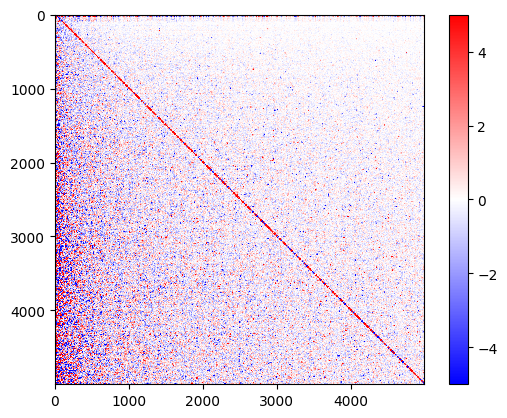

In [ ]:
# New
import matplotlib.pyplot as plt

plt.imshow(B_hat.numpy()[:5000, :5000], cmap='bwr', vmin=-5, vmax = 5)
plt.colorbar()

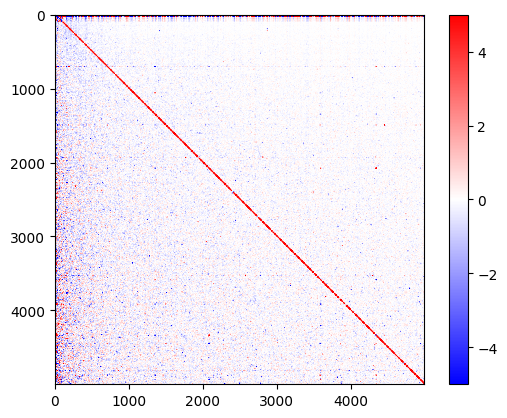

In [ ]:
# Old
import matplotlib.pyplot as plt

plt.imshow(B_hat.numpy()[:5000, :5000], cmap='bwr', vmin=-5, vmax = 5)
plt.colorbar()

In [ ]:
n, X_big.shape

(1000000, torch.Size([1000000, 10000]))

In [ ]:
B_hat.shape, X_batch_e.shape, vanilla_p

(torch.Size([95050, 10000]), torch.Size([8000, 95050]), 10000)

In [ ]:
# Validation loss
i = n - B
X_batch_ = X_big[i : i+B, :].to('cpu').float()
Y_batch_ = Y_big[i : i+B, :].to('cpu').float()

# X_batch__e[:, :vanilla_p] = X_batch_
# binary_ranks = enrich_batch_(X_batch_, X_batch__e)
X_batch_e, binary_ranks, _ = enrich_batch(X_batch_, None)
(((X_batch_e @ B_hat)[..., :vanilla_p] - Y_batch_ * 1000).norm('fro') / (Y_batch_ * 1000).norm('fro')).item()

0.9092625379562378

In [ ]:
error = 0
for _ in range(100):
    i = n - np.random.randint(1, 200)*B
    X_batch_ = X_big[i : i+B, :].to('cpu').float()
    Y_batch_ = Y_big[i : i+B, :].to('cpu').float()

    # X_batch__e[:, :vanilla_p] = X_batch_
    # binary_ranks = enrich_batch_(X_batch_, X_batch__e)
    X_batch_e, binary_ranks, _ = enrich_batch(X_batch_, None)
    error += (((X_batch_e @ B_hat)[..., :vanilla_p] - Y_batch_ * 1000).norm('fro') / (Y_batch_ * 1000).norm('fro')).item()
error / 100
            

0.9405272042751313

In [ ]:
error = 0
for _ in range(100):
    i = 10_000_000 - np.random.randint(1, 1000)*B
    X_batch_ = X_big[i : i+B, :].to('cpu').float()
    Y_batch_ = Y_big[i : i+B, :].to('cpu').float()

    # X_batch__e[:, :vanilla_p] = X_batch_
    # binary_ranks = enrich_batch_(X_batch_, X_batch__e)
    X_batch_e, binary_ranks = enrich_batch(X_batch_, None)
    error += (((X_batch_e @ B_hat)[..., :vanilla_p] - Y_batch_ * 1000).norm('fro') / (Y_batch_ * 1000).norm('fro')).item()
error / 100
            

0.9716556459665299

In [ ]:
#Unlearning
i = 0
X_batch_ = X_big[i : i+B, :].to('cpu').float()
Y_batch_ = Y_big[i : i+B, :].to('cpu').float()

# X_batch__e[:, :vanilla_p] = X_batch_
# binary_ranks = enrich_batch_(X_batch_, X_batch__e)
X_batch_e, binary_ranks = enrich_batch(X_batch_, None)
print((((X_batch_e @ B_hat)[..., :vanilla_p] - Y_batch_ * 1000).norm('fro') / (Y_batch_ * 1000).norm('fro')).item())

0.9696693420410156


In [ ]:
unlearned_B_hat = torch.linalg.solve(first_component + (X_batch_e.T @ X_batch_e), (final_XtY + (X_batch_e.T @ Y_batch_)) @ Y_batch_*1000)

In [ ]:
# Unlearned/validation error:
print((((X_batch_e @ unlearned_B_hat)[..., :vanilla_p] - Y_batch_ * 1000).norm('fro') / (Y_batch_ * 1000).norm('fro')).item())

1.0010663270950317


In [ ]:
(((X_batch_e @ B_hat)[..., :vanilla_p] - Y_batch_ * 1000).norm('fro') / (Y_batch_ * 1000).norm('fro')).item()

0.9674676656723022

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
del final_XtX
del final_XtY
torch.cuda.empty_cache()

In [ ]:
for t in threads[1:]:
    t.join()

RuntimeError: cannot join thread before it is started

In [ ]:
dd = globals().items()
for k, v in dd:
    if hasattr(v, 'device'):
        print(k)
        if v.device == torch.device(device):
            print(f'on {device}', k)

torch
Gemma3ForCausalLM
TOKENS_OF_INTEREST
model
teacher
teacher_matrix
student_matrix
X_big
Y_big


In [ ]:
del XtX_enriched
del XtY_enriched
del X_batch_e
del X_batch
del Y_batch
torch.cuda.empty_cache()
gc.collect()

792

In [ ]:
torch.cuda.empty_cache()
gc.collect()

0

In [ ]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [ ]:
%lprun -f enrich_batch -f foo foo()

  1%|          | 9/1000 [00:36<1:06:45,  4.04s/it]


Timer unit: 1e-09 s

Total time: 0.363381 s
File: /tmp/ipykernel_1659850/3097638200.py
Function: enrich_batch at line 19

Line #      Hits         Time  Per Hit   % Time  Line Contents
    19                                           def enrich_batch(batch, data):
    20        10   77660835.0    8e+06     21.4      binary_masks = binary_rank_feature_extractor(batch, binary_rank_cutoffs)
    21        10     894272.0  89427.2      0.2      torch.cuda.synchronize()
    22        10    1279261.0 127926.1      0.4      logit_features = logit_feature_extractor(batch, logit_offsets)
    23        10     196407.0  19640.7      0.1      torch.cuda.synchronize()
    24                                               # Roots
    25        10     834436.0  83443.6      0.2      roots = batch.abs().sqrt() * batch.sign()
    26        10     153164.0  15316.4      0.0      torch.cuda.synchronize()
    27                                               # Pairwise products of top 100
    28        10   

In [ ]:
torch.cuda.empty_cache()
gc.collect()

0

In [ ]:
XtX_enriched.shape, XtY_enriched.shape, p

(torch.Size([95050, 95050]), torch.Size([95050, 10000]), 95050)

In [ ]:
reg_matrix = 0.1* torch.eye(p, device='cpu') + XtX_enriched.cpu()


In [ ]:
B_hat_enriched = torch.linalg.solve(reg_matrix.to('cuda:4') , XtY_enriched.to('cuda:4')*150000)

NameError: name 'XtY_enriched' is not defined

In [ ]:
X_batch_e.device, B_hat_enriched.device, Y_batch.device

(device(type='cuda', index=6),
 device(type='cuda', index=4),
 device(type='cuda', index=6))

In [ ]:
_X_batch = X_big[i : i+B, :].to(device).float()
_Y_batch = Y_big[i : i+B, :].to(device).float()

_X_batch_e, binary_ranks = enrich_batch(X_batch)
# Outside of the dataset
(((X_batch_e @ B_hat_enriched.to('cuda:6'))[..., :vanilla_p] - Y_batch).norm('fro') / (Y_batch).norm('fro')).item()

In [ ]:
# Part of the dataset
(((X_batch_e @ B_hat_enriched.to('cuda:6'))[..., :vanilla_p] - Y_batch).norm('fro') / (Y_batch).norm('fro')).item()

0.6396805644035339

In [ ]:
XtX_vanilla  += X_batch.T   @ X_batch
torch.cuda.empty_cache()
XtY_vanilla  += X_batch.T   @ Y_batch
torch.cuda.empty_cache()
XtX_enriched += X_batch_e.T @ X_batch_e
torch.cuda.empty_cache()
XtY_enriched += X_batch_e.T @ Y_batch
torch.cuda.empty_cache()

In [ ]:
X_batch_e.T @ X_batch_e

tensor([[8.2446e-02, 5.7372e-02, 5.8677e-05,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.7372e-02, 6.2529e-02, 5.2572e-03,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.8677e-05, 5.2572e-03, 4.5063e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]], dtype=torch.float64)

In [ ]:
import torch
from tqdm import tqdm
# Example sizes
binary_rank_cutoffs = [10, 100, 1000]
logit_offsets  =[1,2,3,4]

'''
    For each cutoff value in cutoffs, a new binary feature is created:
    - The feature is 1 if the value's rank (within its row) is less than the cutoff.
    - The feature is 0 otherwise.
'''
def binary_rank_feature_extractor(batch, cutoffs):
    idx = (-batch).argsort(dim=-1).argsort(dim=-1)
    masks = tuple()
    for cutoff in cutoffs:
        masks = (*masks, idx < cutoff)
    return masks

def logit_feature_extractor(batch, offsets):
    # Values to clamp to after offset
    CLAMP_MIN, CLAMP_MAX = 0, 2
    logits = batch.log()
    new_features = tuple()
    for offset in offsets:
        f = (logits + offset).clamp(CLAMP_MIN, CLAMP_MAX)
        new_features = (*new_features, f)
    return new_features

# Assumes we have probabilities of top_k most frequent tokens, add different order terms
# to capture non-linear relationships between them. e.g. squares, roots, products
def enrich_batch(batch):

    B_size = batch.size(0)
    binary_masks = binary_rank_feature_extractor(batch, binary_rank_cutoffs)
    logit_features = logit_feature_extractor(batch, logit_offsets)
    # Roots
    new_batch = torch.cat((batch, batch.abs().sqrt() * batch.sign()), dim=1)
    # Pairwise products of top 100
    top100 = batch[..., :100].unsqueeze(1)
    idx = torch.triu_indices(100, 100)
    products = top100.mT.matmul(top100)[:, idx[0], idx[1]]
    new_batch = torch.cat((new_batch, products, *binary_masks, *logit_features), dim=1)
    return new_batch, binary_masks

def foo():
    with torch.no_grad():

        n = 10_000_000    # rows
        vanilla_p = 10_000
        p = 20_000 + 5050 + len(binary_rank_cutoffs)*10_000 + len(logit_offsets)*10_000 # features 10K + 10 K (sqrt) + 101C2
        m = 10_000        # targets
        B = 1_000        # batch size
        lambda_ = 0.1 
        device = "cuda:7"   # safer for very large n

        # Create giant matrices for example
        # (in practice you might load from disk instead)
        X_big = student_matrix
        Y_big = teacher_matrix - student_matrix

        # Accumulate
        XtX_vanilla  = torch.zeros((vanilla_p, vanilla_p), device=device, dtype=torch.float64)
        XtY_vanilla  = torch.zeros((vanilla_p, m), device=device, dtype=torch.float64)
        XtX_enriched = torch.zeros((p, p), device=device, dtype=torch.float64)
        XtY_enriched = torch.zeros((p, m), device=device, dtype=torch.float64)

        rank_collector_X = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]
        rank_collector_idx = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]
        enriched_batch = torch.zeros((B, p), device=device, dtype=torch.float64)
        for i in tqdm(range(0, n//10, B)):
            X_batch = X_big[i : i+B, :].to(device).double()
            Y_batch = Y_big[i : i+B, :].to(device).double()
            
            X_batch_e, binary_ranks = enrich_batch(X_batch)
            # for j in range(len(binary_ranks)):
            #     rank_collector_X[j][i] = X_batch[binary_ranks[j]]
            #     rank_collector_idx[j][i] = binary_ranks[j]
            # Y_batch_e = enrich_batch(Y_batch)

            if i==199*B: break
            XtX_vanilla  += X_batch.T   @ X_batch
            torch.cuda.empty_cache()
            XtY_vanilla  += X_batch.T   @ Y_batch
            torch.cuda.empty_cache()
            XtX_enriched += X_batch_e.T @ X_batch_e
            torch.cuda.empty_cache()
            XtY_enriched += X_batch_e.T @ Y_batch
            torch.cuda.empty_cache()
            
        # reg_matrix = lambda_ * torch.eye(p, device=device)

        # Solve for B_hat
        # B_hat = torch.linalg.solve(XtX + reg_matrix, XtY)
        B_hat          = torch.linalg.solve(XtX_vanilla , XtY_vanilla )
        B_hat_enriched = torch.linalg.solve(XtX_enriched, XtY_enriched)

        print(B_hat.shape)
        # Should be (p, m)
    return XtX_vanilla , XtY_vanilla, XtX_enriched, XtY_enriched, X_batch_e, Y_batch, X_batch

# XtX_vanilla , XtY_vanilla, XtX_enriched, XtY_enriched, X_batch_e, Y_batch, X_batch = foo()

In [ ]:
device = 'cuda:5'
with torch.no_grad():

        n = 10_000_000    # rows
        vanilla_p = 10_000
        p = 20_000 + 5050 + len(binary_rank_cutoffs)*10_000 + len(logit_offsets)*10_000 # features 10K + 10 K (sqrt) + 101C2
        m = 10_000        # targets
        B = 1_000        # batch size
        lambda_ = 0.1 
        device = "cuda:7"   # safer for very large n

        # Create giant matrices for example
        # (in practice you might load from disk instead)
        X_big = student_matrix
        Y_big = teacher_matrix - student_matrix

        # Accumulate
        XtX_vanilla  = torch.zeros((vanilla_p, vanilla_p), device=device, dtype=torch.float32)
        XtY_vanilla  = torch.zeros((vanilla_p, m), device=device, dtype=torch.float32)
        XtX_enriched = torch.zeros((p, p), device=device, dtype=torch.float32)
        XtY_enriched = torch.zeros((p, m), device=device, dtype=torch.float32)

        rank_collector_X = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]
        rank_collector_idx = [[0 for _ in range(n//B)] for _ in range(len(binary_rank_cutoffs))]
        enriched_batch = torch.zeros((B, p), device=device, dtype=torch.float32)
        for i in tqdm(range(0, n//10, B)):
            X_batch = X_big[i : i+B, :].to(device)#.double()
            Y_batch = Y_big[i : i+B, :].to(device)#.double()
            
            X_batch_e, binary_ranks = enrich_batch(X_batch)
            # for j in range(len(binary_ranks)):
            #     rank_collector_X[j][i] = X_batch[binary_ranks[j]]
            #     rank_collector_idx[j][i] = binary_ranks[j]
            # Y_batch_e = enrich_batch(Y_batch)

            if i==199*B: break
            XtX_vanilla  += X_batch.T   @ X_batch
            torch.cuda.empty_cache()
            XtY_vanilla  += X_batch.T   @ Y_batch
            torch.cuda.empty_cache()
            XtX_enriched += X_batch_e.T @ X_batch_e
            torch.cuda.empty_cache()
            XtY_enriched += X_batch_e.T @ Y_batch
            torch.cuda.empty_cache()
            
        # reg_matrix = lambda_ * torch.eye(p, device=device)

        # Solve for B_hat
        # B_hat = torch.linalg.solve(XtX + reg_matrix, XtY)
        B_hat          = torch.linalg.solve(XtX_vanilla , XtY_vanilla )
        # B_hat_enriched = torch.linalg.solve(XtX_enriched, XtY_enriched)

        print(B_hat.shape)
        # Should be (p, m)

 20%|█▉        | 199/1000 [03:45<15:05,  1.13s/it]


torch.Size([10000, 10000])


In [ ]:
B_hat_enriched = torch.linalg.solve(XtX_enriched + reg_matrix, XtY_enriched)

In [ ]:
X_batch_e.T @ Y_batch

tensor([[-1.7507e+00, -3.0345e-01, -2.7245e-02,  ...,  4.6076e-06,
          1.4420e-07,  5.7718e-05],
        [-2.5829e-01, -1.3226e+00, -1.6355e-02,  ...,  1.6206e-06,
          1.2095e-08,  1.3191e-06],
        [-1.2334e-02,  6.7503e-02, -1.1208e+00,  ...,  4.1341e-05,
         -1.3481e-06,  1.2737e-07],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]], device='cuda:7')

In [ ]:
torch.cuda.empty_cache()

In [ ]:
XtX_enriched.dtype

torch.float32

In [ ]:
XtX_enriched = XtX_enriched.to('cpu')
reg_matrix = reg_matrix.to('cpu')
XtY_enriched = XtY_enriched.to('cpu')
X_batch_e = X_batch_e.to('cpu')
Y_batch = Y_batch.to('cpu')


In [ ]:
X_batch_e.device, B_hat_enriched_regularized.device, XtX_enriched.device, reg_matrix.device, XtY_enriched.device, Y_batch.device

(device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'))

In [ ]:
X_batch_e.device, B_hat_enriched_regularized.device, Y_batch.device, B_hat.device

(device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'),
 device(type='cuda', index=7))

In [ ]:
B_hat = B_hat.to('cpu')

In [ ]:
reg_matrix

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [ ]:
# lam_vals = [-10, -8, -6, -5,-4,-3,-2,-1,0,1,2]
lam_vals = [-4,-3,-2,-1,0,1,2]
# lam_vals = [-2,-1,0]
# XtY_factors = [10, 100, 1000, 5000, 10000, 50000, 150000]
XtY_factors = [10, 100, 1000]
heatmap_64 = []
device='cpu'
heatmap_64_div_correction = []
for lam in lam_vals:
    ratios = []
    ratios2 = []
    for factor in XtY_factors:
        reg_matrix = 10**lam * torch.eye(p, device=device)
        B_hat_enriched_regularized = torch.linalg.solve(XtX_enriched + reg_matrix, XtY_enriched * factor)
        ratios.append((((X_batch_e @ B_hat_enriched_regularized)[..., :vanilla_p] - Y_batch*factor).norm('fro') / (Y_batch*factor).norm('fro')).item())
        ratios2.append((((X_batch_e @ B_hat_enriched_regularized)[..., :vanilla_p]/factor - Y_batch).norm('fro') / (Y_batch).norm('fro')).item())
    heatmap_64.append(ratios)
    heatmap_64_div_correction.append(ratios2)

In [ ]:
heatmap_64 = np.array(heatmap_64)
heatmap_64_div_correction = np.array(heatmap_64_div_correction)

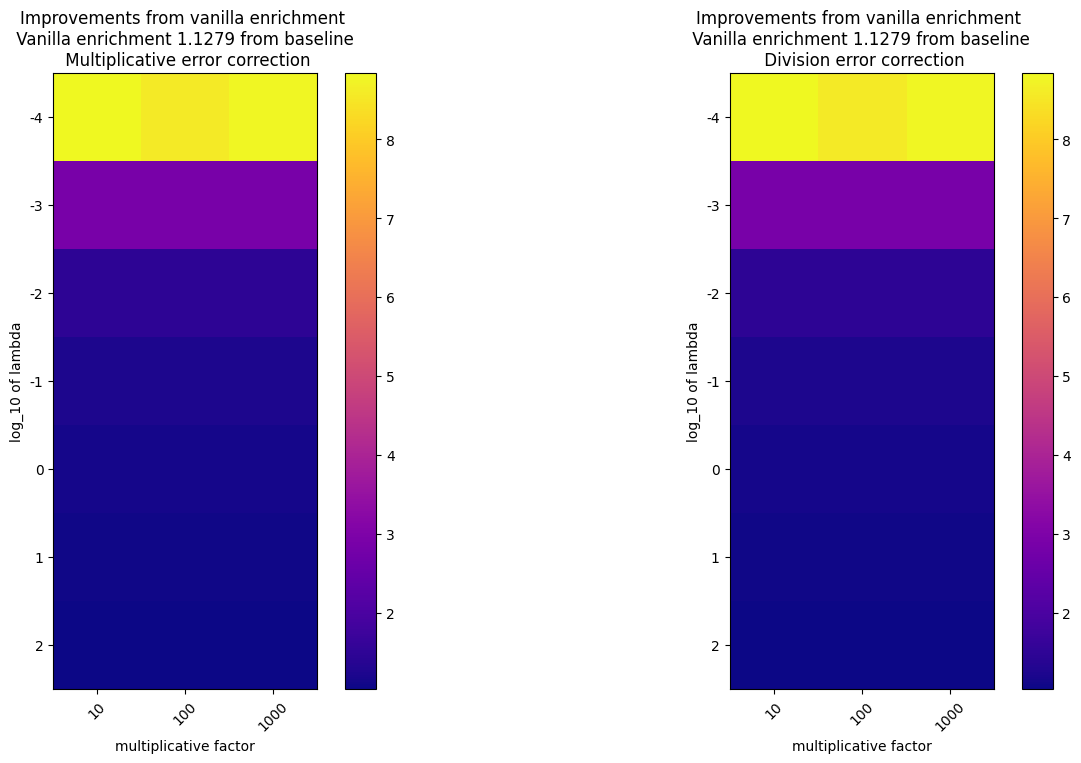

In [ ]:
# Double precision
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Multiplicative error correction")
plt.imshow(heatmap_64, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()
plt.subplot(1,2,2)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Division error correction")
plt.imshow(heatmap_64_div_correction, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()

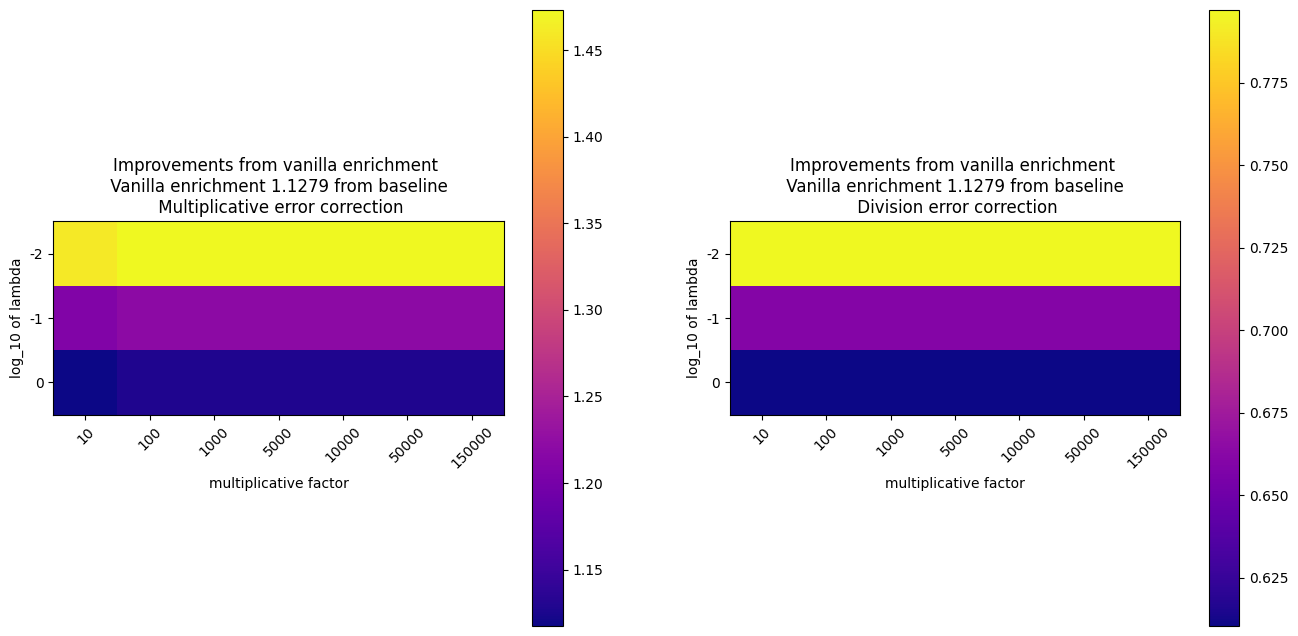

In [ ]:
# Double precision
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Multiplicative error correction")
plt.imshow(heatmap_64, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()
plt.subplot(1,2,2)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Division error correction")
plt.imshow(heatmap_64_div_correction, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()

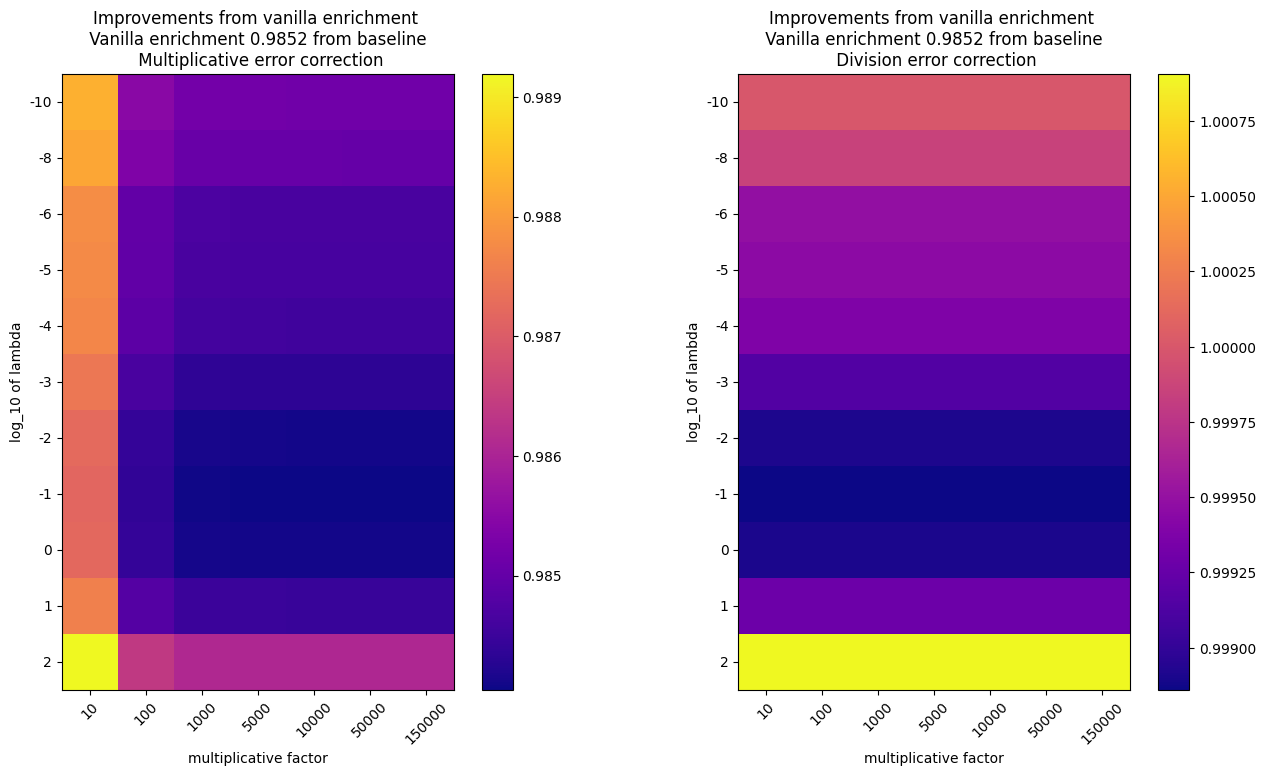

In [ ]:
# Double precision
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Multiplicative error correction")
plt.imshow(heatmap_64, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()
plt.subplot(1,2,2)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Division error correction")
plt.imshow(heatmap_64_div_correction, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()

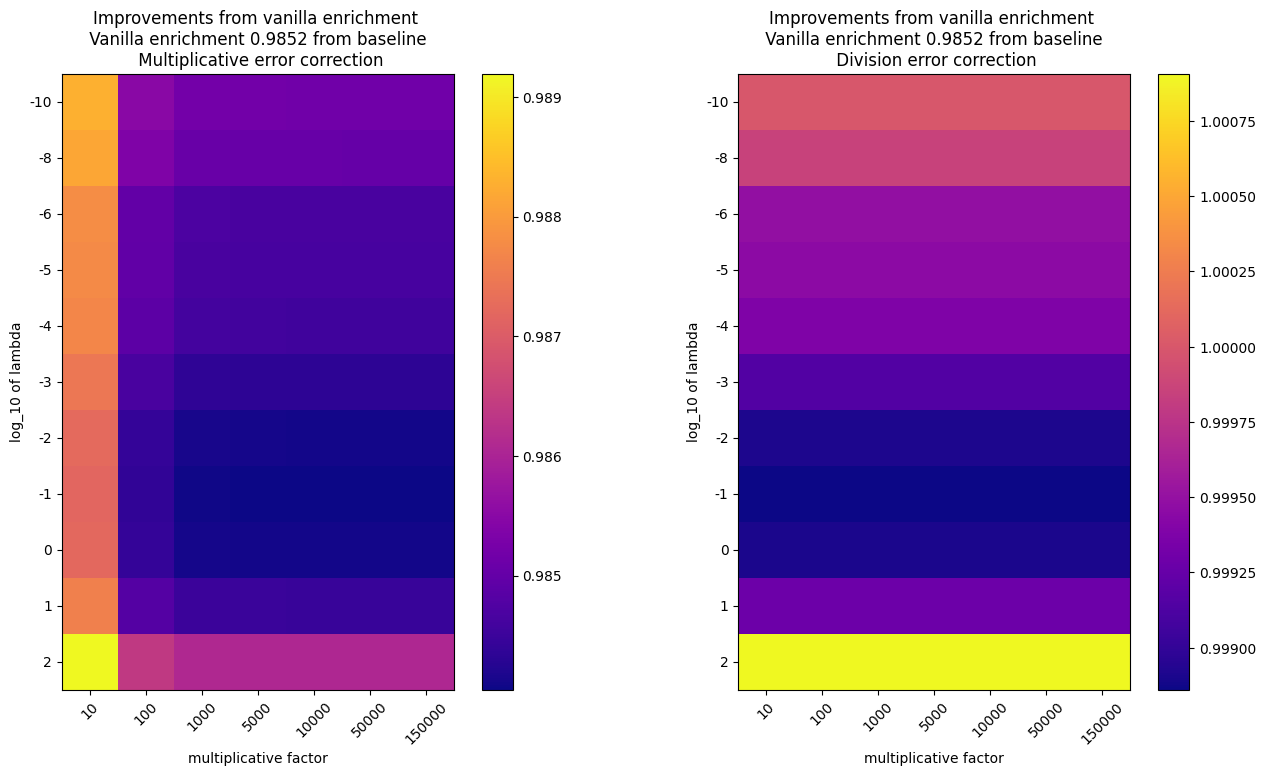

In [ ]:
# Double precision
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Multiplicative error correction")
plt.imshow(heatmap_64, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()
plt.subplot(1,2,2)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Division error correction")
plt.imshow(heatmap_64_div_correction, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()

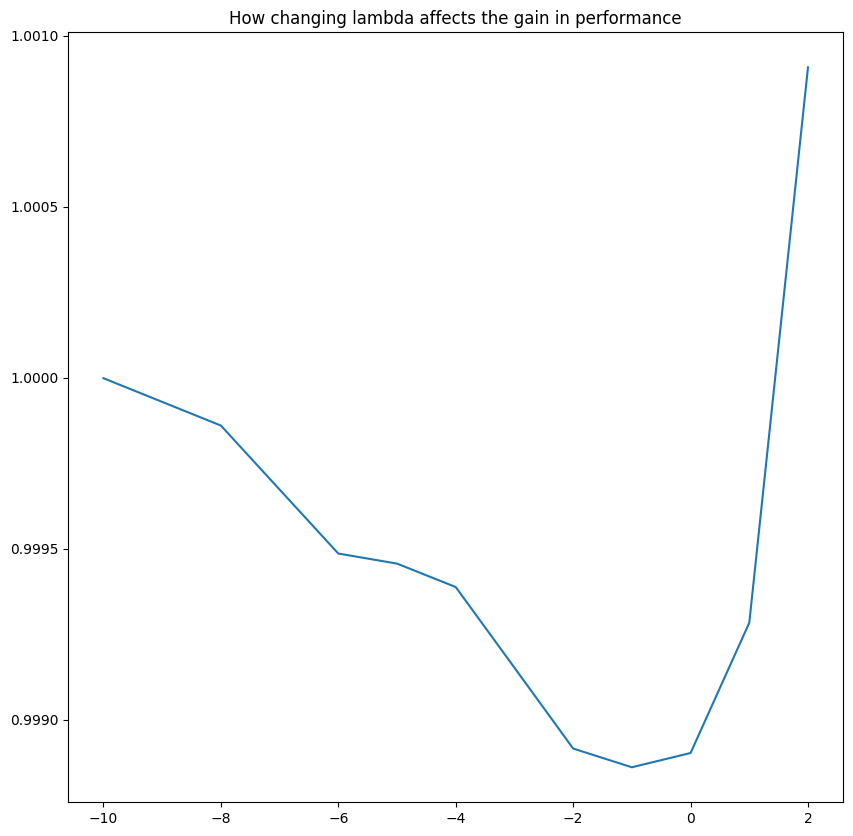

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.title('How changing lambda affects the gain in performance')
lam_vals = [-10, -8, -6, -5,-4,-3,-2,-1,0,1,2]
XtY_factors = [10, 100, 1000, 5000]
heatmap = []
for lam in lam_vals:
    ratios = []
    for factor in XtY_factors:
        reg_matrix = 10**lam * torch.eye(p, device=device)
        B_hat_enriched_regularized = torch.linalg.solve(XtX_enriched + reg_matrix, XtY_enriched * factor)
        ratios.append((((X_batch_e @ B_hat_enriched_regularized)[..., :vanilla_p] - Y_batch).norm('fro') / ((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro')).item())
    heatmap.append(ratios)
# plt.plot(lam_vals, ratios)

### Float 32 study

In [ ]:
import torch
from tqdm import tqdm

# Assumes we have probabilities of top_k most frequent tokens, add different order terms
# to capture non-linear relationships between them. e.g. squares, roots, products
def enrich_batch(batch):
    B_size = batch.size(0)
    # Roots
    new_batch = torch.cat((batch, batch.abs().sqrt() * batch.sign()), dim=1)
    # Pairwise products of top 100
    top100 = batch[..., :100].unsqueeze(1)
    idx = torch.triu_indices(100, 100)
    products = top100.mT.matmul(top100)[:, idx[0], idx[1]]
    new_batch = torch.cat((new_batch, products), dim=1)
    
    return new_batch

# Example sizes
n = 10_000_000    # rows
vanilla_p = 10_000
p = 20_000 + 5050 # features 10K + 10 K (sqrt) + 101C2
m = 10_000        # targets
B = 50_000        # batch size
lambda_ = 0.1 
device = "cuda:7"   # safer for very large n

# Create giant matrices for example
# (in practice you might load from disk instead)
X_big = student_matrix
Y_big = teacher_matrix - student_matrix

# Accumulate
XtX_vanilla  = torch.zeros((vanilla_p, vanilla_p), device=device, dtype=torch.float32)
XtY_vanilla  = torch.zeros((vanilla_p, m), device=device, dtype=torch.float32)
XtX_enriched = torch.zeros((p, p), device=device, dtype=torch.float32)
XtY_enriched = torch.zeros((p, m), device=device, dtype=torch.float32)

for i in tqdm(range(0, n//1, B)):
    X_batch = X_big[i : i+B, :].to(device).float()
    Y_batch = Y_big[i : i+B, :].to(device).float()
    
    X_batch_e = enrich_batch(X_batch)
    # Y_batch_e = enrich_batch(Y_batch)

    if i==199*B: break
    XtX_vanilla  += X_batch.T   @ X_batch
    XtY_vanilla  += X_batch.T   @ Y_batch
    XtX_enriched += X_batch_e.T @ X_batch_e
    XtY_enriched += X_batch_e.T @ Y_batch

# reg_matrix = lambda_ * torch.eye(p, device=device)

# Solve for B_hat
# B_hat = torch.linalg.solve(XtX + reg_matrix, XtY)
B_hat          = torch.linalg.solve(XtX_vanilla , XtY_vanilla )
B_hat_enriched = torch.linalg.solve(XtX_enriched, XtY_enriched)

print(B_hat.shape)
# Should be (p, m)


100%|█████████▉| 199/200 [09:48<00:02,  2.96s/it]


torch.Size([10000, 10000])


In [ ]:
lam_vals = [-10, -8, -6, -5,-4,-3,-2,-1,0,1,2]
XtY_factors = [10, 100, 1000, 5000, 10000, 50000, 150000]
heatmap_32 = []
heatmap_32_div_correction = []
for lam in lam_vals:
    ratios = []
    ratios2 = []
    for factor in XtY_factors:
        reg_matrix = 10**lam * torch.eye(p, device=device)
        B_hat_enriched_regularized = torch.linalg.solve(XtX_enriched + reg_matrix, XtY_enriched * factor)
        ratios.append((((X_batch_e @ B_hat_enriched_regularized)[..., :vanilla_p] - Y_batch*factor).norm('fro') / ((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch*factor).norm('fro')).item())
        ratios2.append((((X_batch_e @ B_hat_enriched_regularized)[..., :vanilla_p]/factor - Y_batch).norm('fro') / ((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro')).item())
    heatmap_32.append(ratios)
    heatmap_32_div_correction.append(ratios2)

In [ ]:
heatmap_32 = np.array(heatmap_32)
heatmap_32_div_correction = np.array(heatmap_32_div_correction)


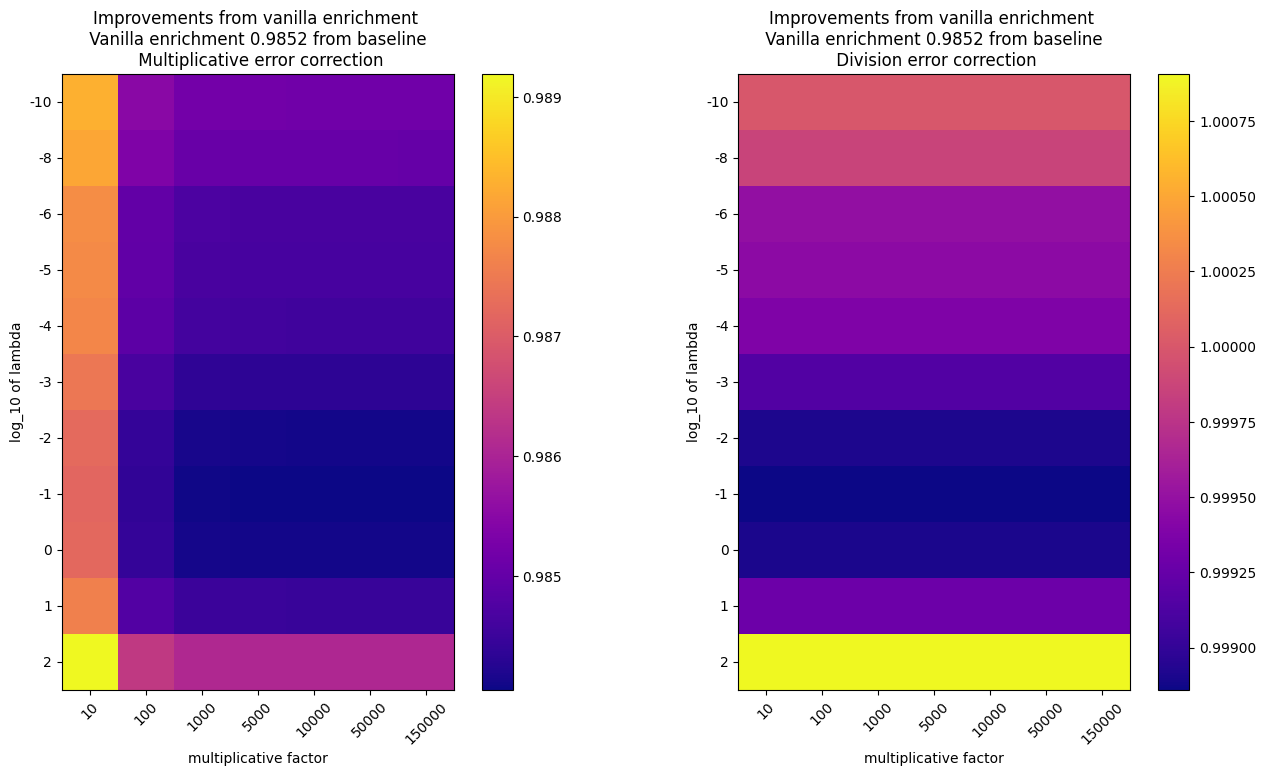

In [ ]:
# FP32 precision
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Multiplicative error correction")
plt.imshow(heatmap_32, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()
plt.subplot(1,2,2)
plt.title(f"Improvements from vanilla enrichment \n Vanilla enrichment {((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / Y_batch.norm():.4f} from baseline \n Division error correction")
plt.imshow(heatmap_32_div_correction, cmap='plasma')
plt.xlabel('multiplicative factor')
plt.xticks(np.arange(len(XtY_factors)), labels=XtY_factors, rotation=45)
plt.ylabel('log_10 of lambda')
plt.yticks(np.arange(len(lam_vals)), labels=lam_vals)
plt.colorbar()

In [ ]:
np.unravel_index(55, heatmap_64.shape)

(7, 6)

In [ ]:
heatmap_64.min(), heatmap_64.shape

(0.9840480131617164, (11, 7))

In [ ]:
heatmap_64.reshape(-1)[55], heatmap_64.min()

(0.9840480131617164, 0.9840480131617164)

In [ ]:
heatmap_64.min(), heatmap_32.min()

(0.9840480131617164, 0.9840483069419861)

In [ ]:
# LSTSQ with sqrt + product enriched targets + regularization 10**-1
((X_batch_e @ B_hat_enriched_regularized)[..., :vanilla_p] - Y_batch).norm('fro') / ((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro')

tensor(0.9993, device='cuda:7', dtype=torch.float64)

In [ ]:
B_hat_enriched = torch.linalg.lstsq(XtX_enriched, XtY_enriched).solution

In [ ]:
B_hat_enriched.shape

torch.Size([30000, 10000])

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# LSTSQ with sqrt + product enriched targets
((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm('fro') / (X_batch @ B_hat - Y_batch).norm('fro')

tensor(0.9965, device='cuda:7', dtype=torch.float64)

In [ ]:
# LSTSQ with sqrt + product enriched targets
((X_batch_e @ B_hat_enriched)[..., :vanilla_p] - Y_batch).norm() / Y_batch.norm(), (X_batch @ B_hat - Y_batch).norm() / Y_batch.norm()

(tensor(0.9852, device='cuda:7', dtype=torch.float64),
 tensor(0.9886, device='cuda:7', dtype=torch.float64))

In [ ]:
# LSTSQ WITHOUT enriched targets
((X_batch_e @ B_hat_enriched)[..., :p//2] - Y_batch).norm() / (X_batch @ B_hat - Y_batch).norm()

tensor(0.9984, device='cuda:3', dtype=torch.float64)

In [ ]:
# LSTSQ WITHOUT enriched targets
((X_batch_e @ B_hat_enriched)[..., :p//2] - Y_batch).norm() / Y_batch.norm(), (X_batch @ B_hat - Y_batch).norm() / Y_batch.norm()

(tensor(0.9870, device='cuda:3', dtype=torch.float64),
 tensor(0.9886, device='cuda:3', dtype=torch.float64))

In [ ]:
# LSTSQ with enriched targets
((X_batch_e @ B_hat_enriched)[..., :p//2] - Y_batch).norm() / (X_batch @ B_hat - Y_batch).norm()

tensor(0.9984, device='cuda:3', dtype=torch.float64)

In [ ]:
# LSTSQ with enriched targets
((X_batch_e @ B_hat_enriched)[..., :p//2] - Y_batch).norm() / Y_batch.norm(), (X_batch @ B_hat - Y_batch).norm() / Y_batch.norm()

(tensor(0.9870, device='cuda:3', dtype=torch.float64),
 tensor(0.9886, device='cuda:3', dtype=torch.float64))

In [ ]:
i = 99 * B
test_X_batch = X_big[i : i+B, :].to(device).double()
test_Y_batch = Y_big[i : i+B, :].to(device).double()
test_X_batch_enriched = enrich_batch(test_X_batch)
test_Y_batch_enriched = enrich_batch(test_Y_batch)
XtX_vanilla_test = XtX_vanilla - test_X_batch.T @ test_X_batch
XtY_vanilla_test = XtY_vanilla - test_X_batch.T @ test_Y_batch
XtX_enriched_test = XtX_enriched - test_X_batch_enriched.T @ test_X_batch_enriched
XtY_enriched_test = XtY_enriched - test_X_batch_enriched.T @ test_Y_batch_enriched

In [ ]:
i = 0 * B
device = 'cpu'
test_X_batch = X_big[i : i+B, :].to(device).double()
test_Y_batch = Y_big[i : i+B, :].to(device).double()
test_X_batch_enriched = enrich_batch(test_X_batch)
test_Y_batch_enriched = enrich_batch(test_Y_batch)

In [ ]:
B_hat_test          = torch.linalg.solve(XtX_vanilla_test , XtY_vanilla_test )
B_hat_enriched_test = torch.linalg.solve(XtX_enriched_test, XtY_enriched_test)


In [ ]:
(test_X_batch @ B_hat_test - Y_batch).norm() / (test_X_batch @ B_hat_test * 0 - Y_batch).norm()

tensor(1.0120, device='cuda:3', dtype=torch.float64)

In [ ]:
((test_X_batch_enriched.cpu() @ B_hat_enriched_test.cpu())[..., :p//2] - Y_batch.cpu()).norm() / (Y_batch.cpu()).norm()

tensor(1.0141, dtype=torch.float64)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# B_hat = torch.linalg.lstsq(X_batch, Y_batch*1_000).solution
#B_hat = torch.linalg.lstsq(XtX, XtY*1).solution
B_hat = torch.linalg.solve(XtX, XtY)

# for i in range(0, n//50, B):
#     X_batch = X_big[i : i+B, :].to('cuda:2').double()
#     Y_batch = Y_big[i : i+B, :].to('cuda:2').double()
#     error1=(X_batch.to('cuda:1') @ B_hat.to('cuda:1')    - Y_batch.to('cuda:1')).norm()
#     error2=(X_batch.to('cuda:1') @ B_hat.to('cuda:1') *0 - Y_batch.to('cuda:1')).norm()
#     print(error1/error2,error1,error2)


In [ ]:
error1, error2, error1/error2

(tensor(75.9889, device='cuda:1', dtype=torch.float64),
 tensor(76.7455, device='cuda:1', dtype=torch.float64),
 tensor(0.9901, device='cuda:1', dtype=torch.float64))

In [ ]:
error1=(X_batch.to('cuda:1') @ B_hat.to('cuda:1')    - Y_batch.to('cuda:1')).norm()
error2=(X_batch.to('cuda:1') @ B_hat.to('cuda:1') *0 - Y_batch.to('cuda:1')).norm()

In [ ]:
r=X_batch.to('cuda:1') @ B_hat.to('cuda:1')
r.mean()

tensor(-6.1274e-07, device='cuda:1', dtype=torch.float64)

In [ ]:
r.std()

tensor(0.0004, device='cuda:1', dtype=torch.float64)

In [ ]:
1- What is the effect of regularization?
2- How adding features would work (for example, adding square root of inputs)
3- What about only training for the top 100 values
4- How would the trick of KL divergence work?
5- try less bits and see how and if the multiplicative factor for Y starts to affect things

In [ ]:
from tqdm import tqdm
B_hat=B_hat.to('cuda:2')


In [ ]:
errors = X_big[:B, :].double() @ B_hat.cpu() - Y_big[:B].double()

In [ ]:
errors_baseline = (Y_big[:B].double()).abs().sum()

In [ ]:
errors.abs().sum()/errors_baseline

tensor(2.0808, dtype=torch.float64)

In [ ]:
reg_matrix = lambda_ * torch.eye(p, device=device)

explicit_B_hat = XtX.inverse() @ XtY
reg_matrix = reg_matrix.double()
explicit_B_hat_reg = (XtX + reg_matrix*1000000000).inverse() @ XtY


In [ ]:
explicit_B_hat_regs = [(XtX + reg_matrix*(10**k)).inverse() @ XtY for k in [8, 10, 12, 14]]

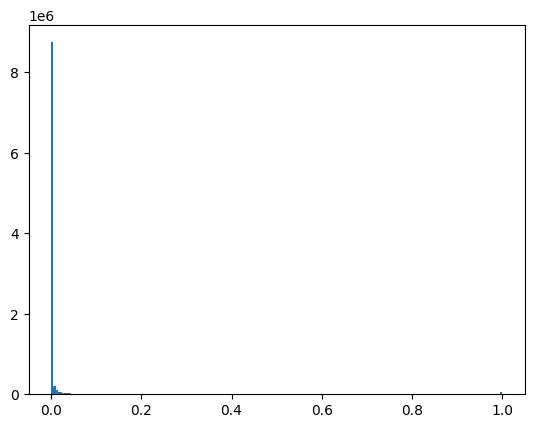

In [ ]:
import matplotlib.pyplot as plt

(explicit_B_hat - B_hat).abs().max()
plt.hist(teacher_matrix[:, 0].numpy(), bins=200);

1.0572293792294558 - 10000
1.0127918054785299 - 1000000
1000000000

In [ ]:
error1 = torch.zeros(1).to(torch.float64).to('cuda:2')
error1_explicit = torch.zeros(1).to(torch.float64).to('cuda:2')
error1_explicit_reg = [torch.zeros(1).to(torch.float64).to('cuda:2') for _ in range(len(explicit_B_hat_regs))]
baseline_error = torch.zeros(1).to(torch.float64).to('cuda:2')
for i in tqdm(range(0, n//100, B)):
    X_batch = X_big[i : i+B, :].to('cuda:2').double()
    Y_batch = Y_big[i : i+B, :].to('cuda:2').double()
    baseline_error += (X_batch @ (B_hat * 0) - Y_batch).abs().sum()
    error1 += (X_batch @ (B_hat) - Y_batch).abs().sum()
    error1_explicit += (X_batch @ (explicit_B_hat) - Y_batch).abs().sum()
    for j, reg in enumerate(explicit_B_hat_regs):
        error1_explicit_reg[j] += (X_batch @ (reg) - Y_batch).abs().sum()
    
print((error1 / baseline_error).item(), f" - torch.solve")
print((error1_explicit / baseline_error).item(), f" - manual inversion")
for j, err in enumerate(error1_explicit_reg):
    print((error1_explicit_reg / baseline_error).item(), f" - regularized with lambda = 10**{[8, 10, 12, 14][j]}")

100%|██████████| 10/10 [00:33<00:00,  3.35s/it]


1.1302568634302728  - torch.solve
1.1302568634302728  - manual inversion


TypeError: unsupported operand type(s) for /: 'list' and 'Tensor'

In [ ]:
for j, err in enumerate(error1_explicit_reg):
    print(err / baseline_error, f"10 ** {[8, 10, 12, 14][j]}")

tensor([1.0001], device='cuda:2', dtype=torch.float64) 10 ** 8
tensor([1.0000], device='cuda:2', dtype=torch.float64) 10 ** 10
tensor([1.0000], device='cuda:2', dtype=torch.float64) 10 ** 12
tensor([1.0000], device='cuda:2', dtype=torch.float64) 10 ** 14


In [ ]:
for i in range(5):
    IX=np.random.randint(10000000)
    print(student_matrix[IX,:].sort().indices[-5:].tolist())
    print(student_matrix[IX,:].sort().values [-5:].tolist())
    print(teacher_matrix[IX,:].sort().indices[-5:].tolist())
    print(teacher_matrix[IX,:].sort().values [-5:].tolist())
    print()




[1, 19, 14, 16, 7]
[0.004241943359375, 0.0108642578125, 0.07080078125, 0.11669921875, 0.76171875]
[1, 19, 14, 16, 7]
[0.00244140625, 0.01239013671875, 0.026123046875, 0.1708984375, 0.765625]

[6, 117, 5, 10, 1]
[0.008544921875, 0.00970458984375, 0.0810546875, 0.220703125, 0.59765625]
[26, 1094, 1, 10, 168]
[0.0286865234375, 0.04736328125, 0.1650390625, 0.271484375, 0.396484375]

[4832, 2153, 14, 1222, 2]
[0.031005859375, 0.048095703125, 0.048095703125, 0.054443359375, 0.16796875]
[1509, 5851, 229, 1721, 2]
[0.037841796875, 0.048583984375, 0.048583984375, 0.07080078125, 0.0908203125]

[6370, 3617, 8731, 6154, 9000]
[0.000469207763671875, 0.0009918212890625, 0.00144195556640625, 0.00185394287109375, 0.9609375]
[4236, 9942, 3617, 8731, 9000]
[0.0012969970703125, 0.00188446044921875, 0.00213623046875, 0.005126953125, 0.86328125]

[27, 59, 1, 11, 73]
[0.006256103515625, 0.01165771484375, 0.01324462890625, 0.11083984375, 0.8203125]
[59, 326, 1, 11, 73]
[0.0164794921875, 0.0185546875, 0.02392

In [ ]:
XtY[:, 0]

tensor([-1.0153e+04, -1.3914e+03, -2.7396e+00,  ...,  3.2479e-02,
        -1.1767e-02, -2.4255e-02], device='cuda:2', dtype=torch.float64)

In [ ]:
(XtY - XtY.T).max()

tensor(1698.1828, device='cuda:2', dtype=torch.float64)

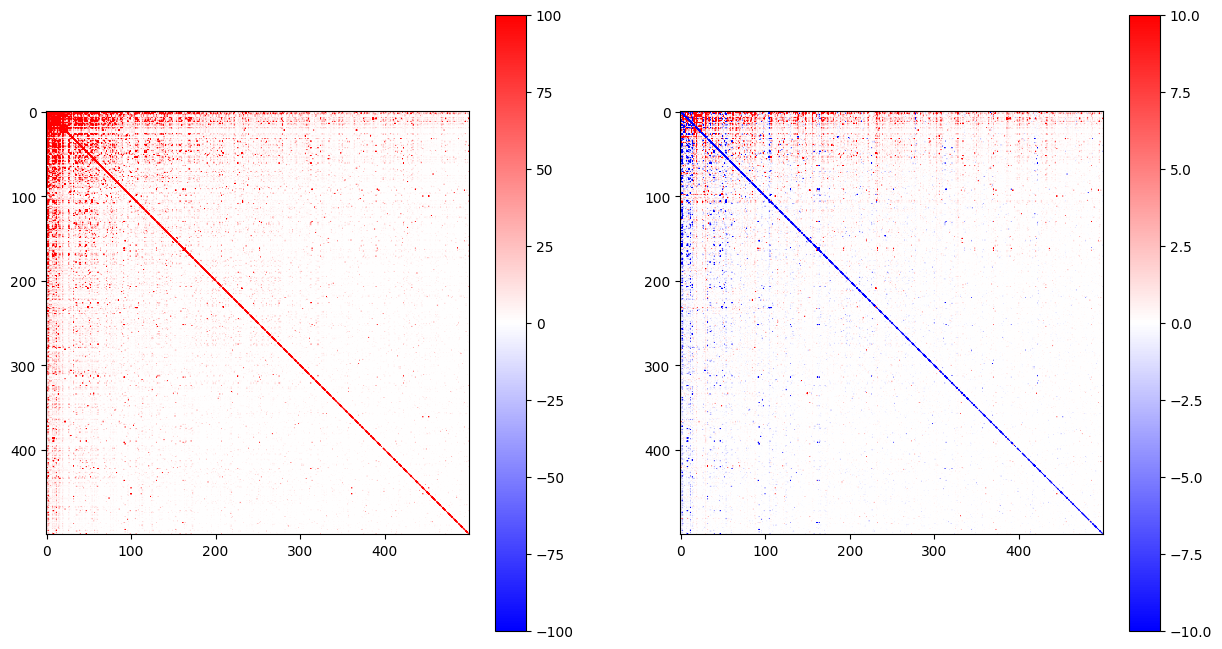

In [ ]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.imshow(XtX[0:500,0:500].cpu().numpy(),cmap='bwr',vmin=-100,vmax=100)
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(XtY[0:500,0:500].cpu().numpy(),cmap='bwr',vmin=-10,vmax=10)
plt.colorbar()


In [ ]:
import torch

def compute_vif_torch(X):
    """
    Compute VIF for each feature in X using PyTorch.

    X : torch.Tensor
        (n_samples, n_features)
    
    Returns
    -------
    vif : torch.Tensor
        (n_features,)
    """
    n, p = X.shape
    vif = torch.zeros(p, dtype=X.dtype, device=X.device)

    # Mean center X to avoid fitting intercept
    X_centered = X - X.mean(dim=0, keepdim=True)

    for j in tqdm(range(p)):
        # X_j is the target
        X_j = X_centered[:, j]

        # X_minus_j is all other features
        X_minus_j = torch.cat([X_centered[:, :j], X_centered[:, j+1:]], dim=1)

        # Solve least squares: X_j ~ X_minus_j
        # beta_hat = (X^T X)^{-1} X^T y
        XtX = X_minus_j.T @ X_minus_j
        Xty = X_minus_j.T @ X_j

        try:
            beta_hat = torch.linalg.solve(XtX, Xty)
        except RuntimeError:
            # Matrix may be singular; fallback to pseudo-inverse
            beta_hat = torch.linalg.pinv(XtX) @ Xty

        # Predicted X_j
        X_j_hat = X_minus_j @ beta_hat

        # Compute R²
        ss_res = torch.sum((X_j - X_j_hat) ** 2)
        ss_tot = torch.sum((X_j - X_j.mean()) ** 2)

        R_squared = 1 - ss_res / ss_tot if ss_tot > 0 else torch.tensor(0.0, device=X.device)

        vif[j] = 1.0 / (1.0 - R_squared + 1e-12)  # add epsilon for stability

    return vif

vif = compute_vif_torch(X_big)

In [ ]:
teacher.lm_head, model.lm_head

(Linear(in_features=2560, out_features=262208, bias=False),
 Linear(in_features=1152, out_features=262144, bias=False))

0.0021426814288969497


2.1708748120555264e-05




2.1711616152070554e-07


2.1711644837345355e-09




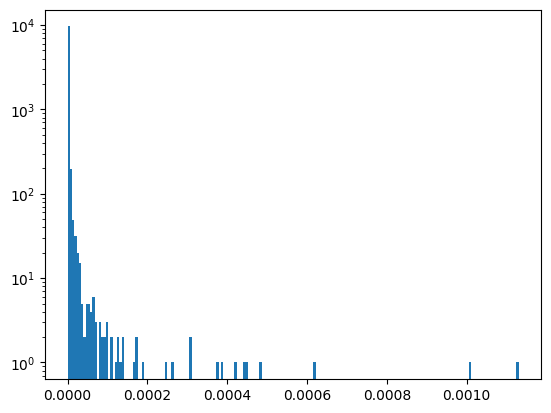

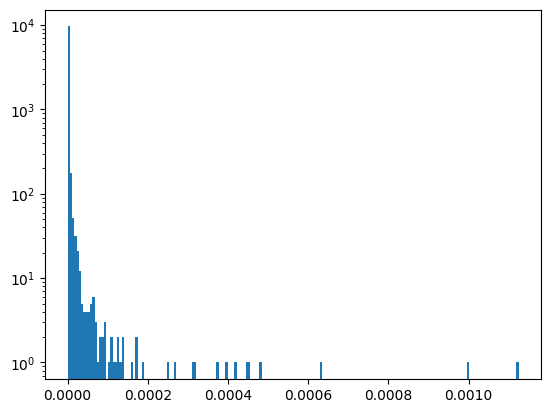

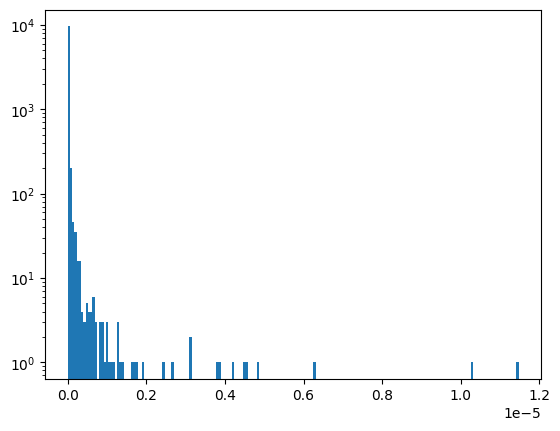

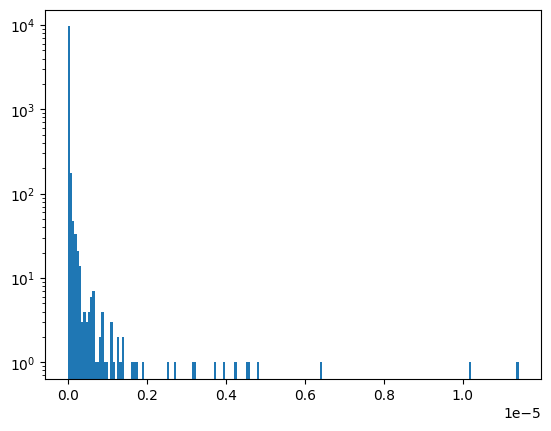

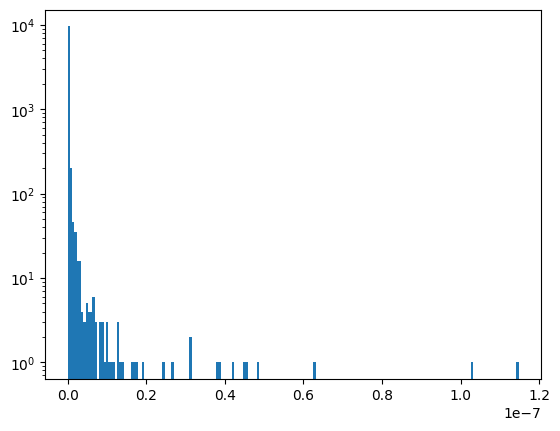

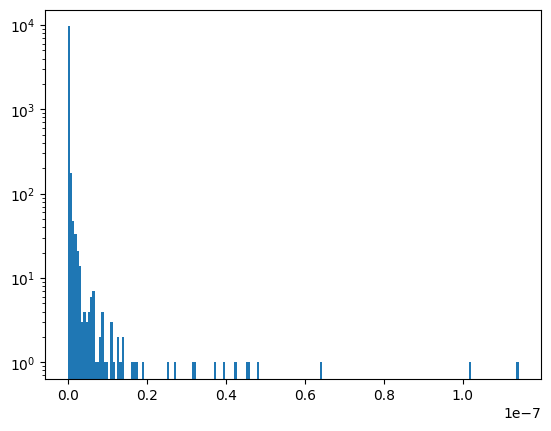

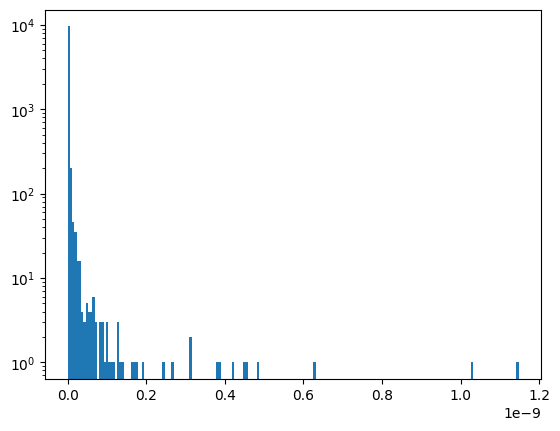

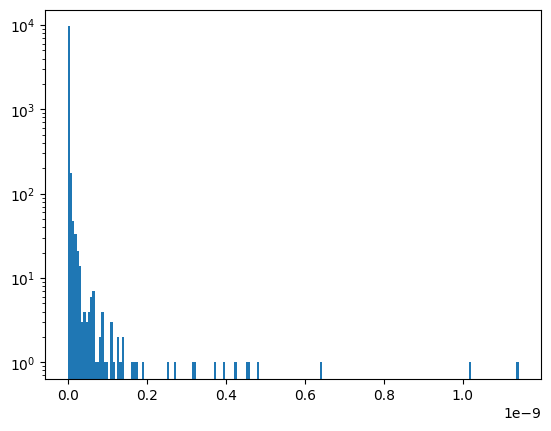

In [ ]:
for reg in explicit_B_hat_regs:
    print(reg.norm().item())
    plt.figure()
    plt.hist(reg.norm(dim=0).cpu().detach().numpy(), bins=200);
    plt.yscale('log')
    plt.figure()
    plt.hist(reg.norm(dim=1).cpu().detach().numpy(), bins=200);
    plt.yscale('log')
    print()
    print()


In [ ]:
Y_big.max()

tensor(1.)

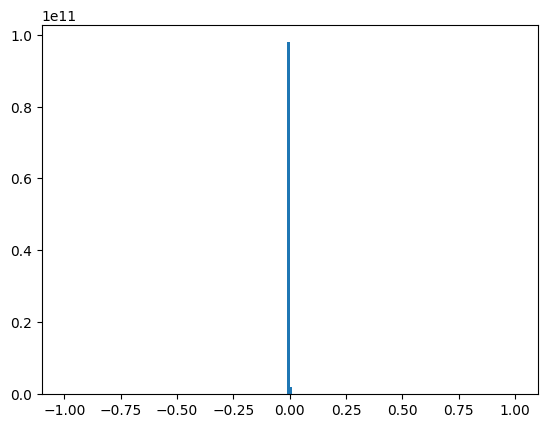

In [ ]:
plt.hist(Y_big.numpy().reshape(-1), bins=200);

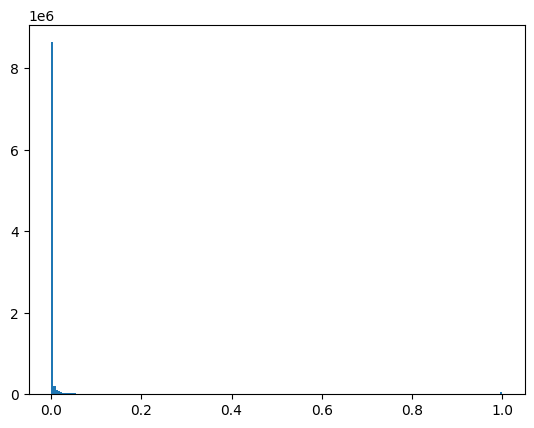

In [ ]:
plt.hist(student_matrix[:, 0].numpy(), bins=200);

In [ ]:
B_hat.dtype

torch.float64

In [ ]:
error = 0
for i in range(0, n, B):
    X_batch = X_big[i : i+B, :].to('cuda:2').float()
    Y_batch = Y_big[i : i+B, :].to('cuda:2').float()
    error += (X_batch @ B_hat - Y_batch).abs().sum()
print(error)

tensor(4614239.5000, device='cuda:2')


In [ ]:
B_hat2=B_hat.clone()

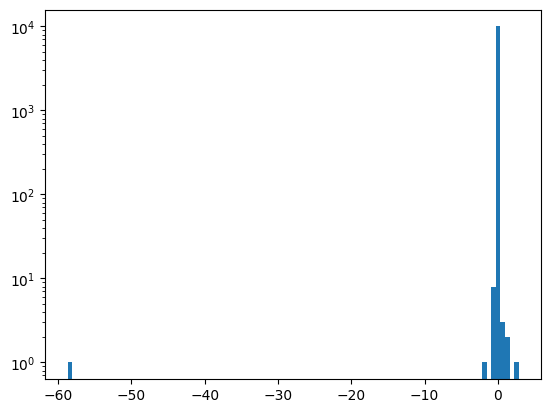

In [ ]:
plt.hist(B_hat.sum(dim=1).cpu().numpy(),bins=100)
plt.yscale('log')

In [ ]:
# Regularization run
from tqdm import tqdm
error1 = torch.zeros(1).to(torch.float64).to('cuda:2')
error2 = torch.zeros(1).to(torch.float64).to('cuda:2')
B_hat=B_hat.to('cuda:2')
for i in tqdm(range(0, n//10, B)):
    X_batch = X_big[i : i+B, :].to('cuda:2').float()
    Y_batch = Y_big[i : i+B, :].to('cuda:2').float()
    error1 += (X_batch @ (B_hat) - Y_batch).abs().sum()
    error2 += (X_batch @ (B_hat*0) - Y_batch).abs().sum()
print(error1/error2)

100%|██████████| 10/10 [00:15<00:00,  1.59s/it]


tensor([1.1300], device='cuda:2', dtype=torch.float64)


In [ ]:
# Float 32 run
from tqdm import tqdm
error1 = torch.zeros(1).to(torch.float64).to('cuda:2')
error2 = torch.zeros(1).to(torch.float64).to('cuda:2')
B_hat=B_hat.to('cuda:2')
for i in tqdm(range(0, n//10, B)):
    X_batch = X_big[i : i+B, :].to('cuda:2').float()
    Y_batch = Y_big[i : i+B, :].to('cuda:2').float()
    error1 += (X_batch @ (B_hat) - Y_batch).abs().sum()
    error2 += (X_batch @ (B_hat*0) - Y_batch).abs().sum()
print(error1/error2)

100%|██████████| 10/10 [00:22<00:00,  2.26s/it]


tensor([1.1303], device='cuda:2', dtype=torch.float64)


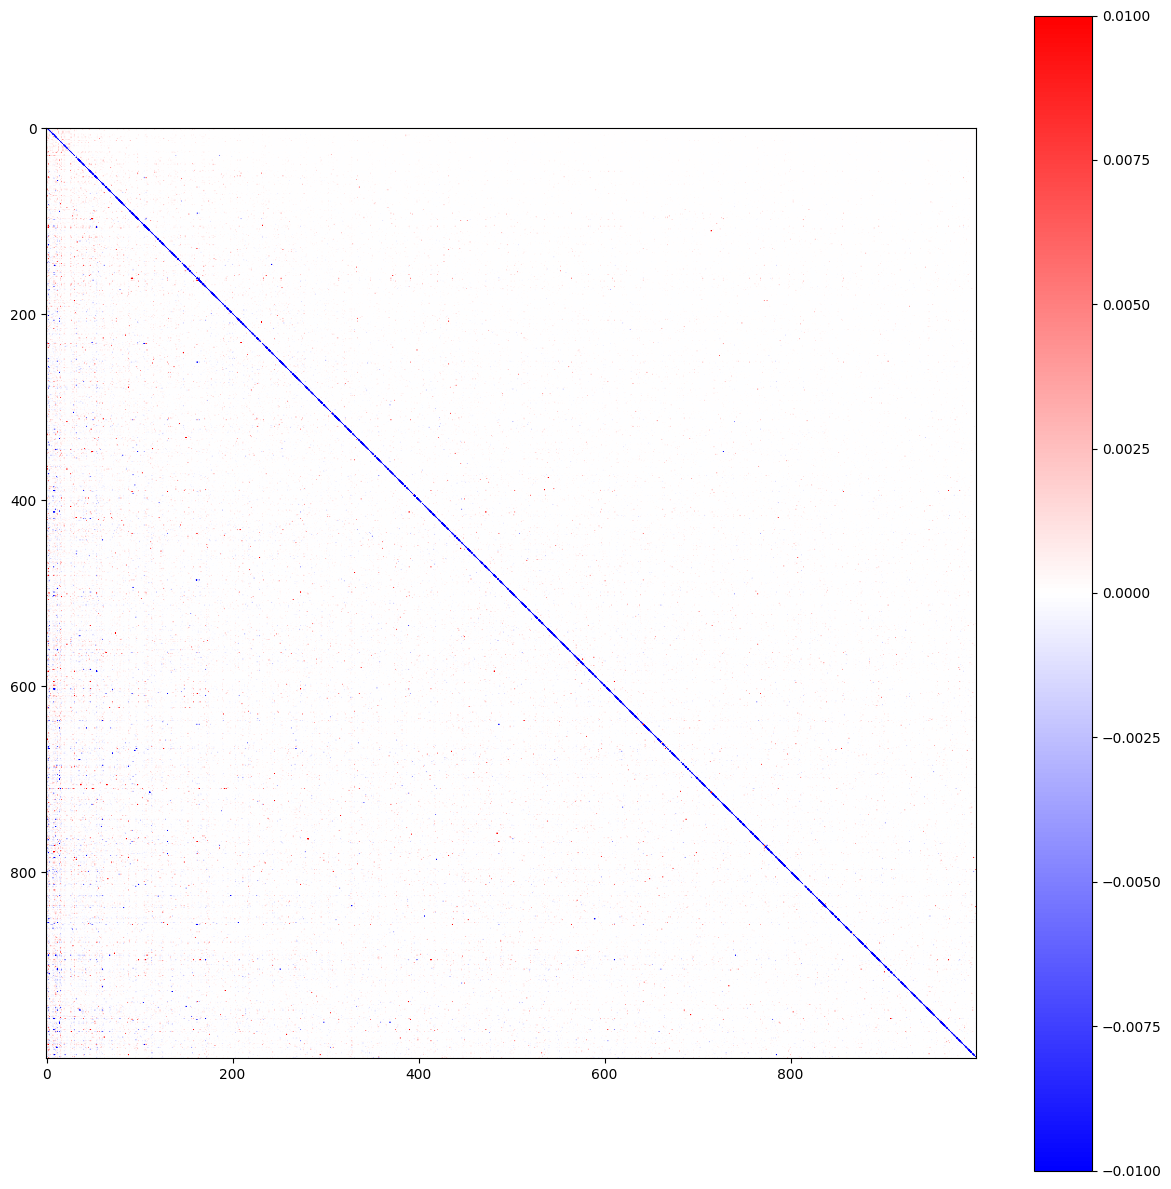

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
plt.imshow(B_hat[0:1000,0:1000].cpu().numpy(),cmap='bwr',vmin=-0.01,vmax=0.01)
plt.colorbar()

In [ ]:
X_big.nbytes / 10 ** 9, Y_big.nbytes / 10 ** 9

(400.0, 400.0)

In [ ]:
baseline_error = Y_big.abs().sum()
print(baseline_error)

tensor(4086899.2500)


In [ ]:
error / baseline_error

tensor(1.1293, device='cuda:2')

In [ ]:
a = torch.tensor(1, dtype=torch.float, requires_grad=True)
b = torch.tensor(1, dtype=torch.float, requires_grad=True)
c = torch.tensor(1, dtype=torch.float, requires_grad=True)
s = a + b + c 

In [ ]:
s.backward()

In [ ]:
a.grad

tensor(1.)

In [ ]:
from torch.autograd import grad
grad(s, a)

(tensor(1.),)

In [ ]:
error

tensor(4859470.5000, device='cuda:2')

In [ ]:
error / X_big.nelement()

tensor(4.6152e-05, device='cuda:2')

In [ ]:
torch.cuda.empty_cache()

In [ ]:
(X_big.to('cuda:2') @ B_hat - Y_big.to('cuda:2')).abs.sum()

OutOfMemoryError: CUDA out of memory. Tried to allocate 372.53 GiB. GPU  has a total capacity of 79.10 GiB of which 69.57 GiB is free. Including non-PyTorch memory, this process has 9.52 GiB memory in use. Of the allocated memory 8.60 GiB is allocated by PyTorch, and 2.61 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import os
model_dir = '/image-generation/imlloja/distillation/models/forced_increments/adamw/fixed_alpha=1e-3/mean_normed_grads/BASELINE/weight_decay_100_gemma1_gemma4_lr_0.0001_torch.bfloat16_batchsize_4_residual_accSteps=10_cutoffs _[0, 1000]_counts _[10]_factor_0.001_LN'
files = sorted(os.listdir(model_dir), key=lambda x : int(x[:-4]))

In [ ]:
modelpath10 = '/image-generation/imlloja/distillation/models/forced_increments/adamw/alpha0.1/weight_decay_0.1_gemma1_gemma4_lr_1e-05_torch.bfloat16_batchsize_4_residual_accSteps=2000_cutoffs _[0, 10000]_counts _[1]_factor_1_LN/10.pth'

modelpath330 = '/image-generation/imlloja/distillation/models/forced_increments/adamw/alpha0.1/weight_decay_0.1_gemma1_gemma4_lr_1e-05_torch.bfloat16_batchsize_4_residual_accSteps=2000_cutoffs _[0, 10000]_counts _[1]_factor_1_LN/330.pth'

cpt10 = torch.load(modelpath10)
cpt330 = torch.load(modelpath330)


In [ ]:
m10=cpt10['proj.weight'].float()
m330=cpt330['proj.weight'].float()
print(m10.norm())
print(m330.norm())
print( (m10-m330).norm())

#.cpu().detach().numpy()

tensor(45.4458, device='cuda:3')
tensor(45.5725, device='cuda:3')
tensor(4.3406, device='cuda:3')


In [ ]:
m10.shape

torch.Size([10000, 1152])

In [ ]:
cpt['proj.weight'].float().norm()#.cpu().detach().numpy()

In [ ]:
cpt['proj.weight'].norm(dim=1).float().cpu().detach().numpy().max()

0.48046875

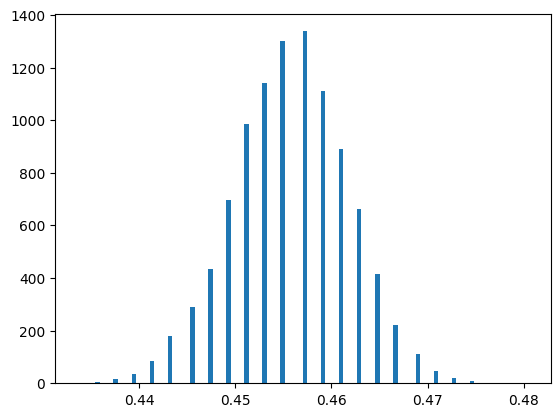

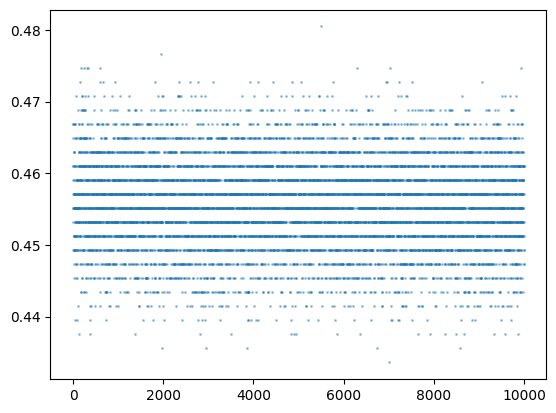

In [ ]:
import matplotlib.pyplot as plt

plt.hist(cpt['proj.weight'].norm(dim=1).float().cpu().detach().numpy(), bins=100);
plt.show()
plt.scatter(np.arange(10000), cpt['proj.weight'].norm(dim=1).float().cpu().detach().numpy(), s=1, alpha=0.4)
# plt.ylim(0.4, 0.5)

In [ ]:
TOKENS_OF_INTEREST = torch.tensor(np.fromfile("gemma3_TOI", dtype=np.int32))
devices = [f'cuda:{i}' for i in [0,1,4,5,6,7]]

weight_type = (torch.bfloat16 if True or args.weight_type == "bf16" else torch.float32)

model   = Gemma3ForCausalLM.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[0])  
teacher = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja", torch_dtype=weight_type, device_map = devices[1])  
tokenizer   = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/image-generation/imlloja")
ds = load_from_disk("/image-generation/imlloja/filtered-math")
# ds = torch.utils.data.Subset(ds, range(10000, len(ds)))
scaler = GradScaler()

lr = 0.005
neuron_counts = torch.ones(model.lm_head.weight.shape[0], dtype=torch.int32)
print("Running experiment")
configuration = {
    'log_path' : "debugging/forward_inject/withdiv",
    'teacher_model' : teacher,
    'student_model' : model,
    'optimizer' : lambda y : lambda x : torch.optim.Adam(x, lr=y, eps=1e-6),
    'log_step' : 1,
    # 'accumulation_steps' : args.accumulation_steps,
    'target' : "residual",
    'type' : weight_type,
    'ln' : "1",
    'noise_init_fn' : lambda x : torch.nn.init.normal_(x, mean=0, std=0.03),
    'line_length' : 1000,
    'batch_size' : 4,
    'experiments' : [
        # {
        #     'cutoffs' : [0, 1],
        #     'counts'  : [0],
        #     'accumulation_steps' : 1,
        #     'init_factor' : 0,
        #     'lr' : 0.005
        # },
        # {
        #     'cutoffs' : [0, 1],
        #     'counts'  : [0],
        #     'accumulation_steps' : 10,
        #     'init_factor' : 0,
        #     'lr' : 0
        # },
        {
            'cutoffs' : [0, 1],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1
        },
        {
            'cutoffs' : [0, 10000],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1
        },
        {
            'cutoffs' : [0, 1],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1,
            'forward_inject' : True
        },
        {
            'cutoffs' : [0, 10000],
            'counts'  : [1],
            'accumulation_steps' : 1000,
            'init_factor' : 0,
            'lr' : 0.1,
            'forward_inject' : True
        },
        # {
        #     'cutoffs' : [0, 1000, 2000, 10000],
        #     'counts'  : [128, 64, 8],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 2000, 5000, 8000],
        #     'counts'  : [256, 64, 16, 2],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 1000,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 2000, 5000, 8000],
        #     'counts'  : [256, 64, 16, 2],
        #     'accumulation_steps' : 500,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 500,
        #     'init_factor' : 0
        # },
        # {
        #     'cutoffs' : [0, 400, 5000, 8000],
        #     'counts'  : [256, 32, 2],
        #     'accumulation_steps' : 1500,
        #     'init_factor' : 0
        # },
    ],
}
VOCABSIZE = tokenizer.vocab_size
    
for experimentjson in configuration['experiments']:
    lr = experimentjson['lr']
    factor = experimentjson['init_factor']
    experimentjson['optimizer'] = configuration['optimizer'](lr)
    experimentjson['experiment_name'] = f"{'one_step' if 'forward_inject' in experimentjson else 'two_steps'}_gemma1_gemma4_lr_{lr}_{weight_type}_batchsize_{configuration['batch_size']}_{configuration['target']}_accSteps={experimentjson['accumulation_steps']}_cutoffs _{experimentjson['cutoffs']}_counts _{experimentjson['counts']}_factor_{factor}{'_LN'if configuration['ln']=='1' else '_noLN'}"
    experimentjson['counts'] = torch.tensor(experimentjson['counts'])
    experimentjson['cutoffs'] = torch.tensor(experimentjson['cutoffs'])
    experimentjson['backward_steps'] = 0
    forward_diff = experimentjson['cutoffs'][1:] - experimentjson['cutoffs'][:-1]
    experimentjson['neuron_counts'] = torch.repeat_interleave(experimentjson['counts'], forward_diff)
    # for i in range(len(experimentjson['inflated_decoder_sizes']['cutoffs'])-1):
    #     counts, cutoffs = experimentjson['inflated_decoder_sizes']['counts'], experimentjson['inflated_decoder_sizes']['cutoffs']
    #     experimentjson['neuron_counts'][cutoffs[i] : cutoffs[i+1]] = counts[i]

loader = torch.utils.data.DataLoader(ds, batch_size=configuration['batch_size'], shuffle=False)
configuration['loader'] = loader

# train_loop(configuration)
# main(configuration)
# queues_loop(configuration)
# naive(configuration)



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

Running experiment


In [ ]:
student_model = configuration['student_model']
teacher_model = configuration['teacher_model']
dataloader = configuration['loader']
for i, experiment in enumerate(configuration['experiments']):
    experiment['writer'] = SummaryWriter(f"{configuration['log_path']}/{experiment['experiment_name']}")
    decoder_device = devices[i+2]
    counts = experiment['neuron_counts']
    experiment['inflated_decoder'] = SparseResidualDecoder(student_model, counts, decoder_device, configuration['type'], configuration['ln']=="1", experiment['init_factor'])
    experiment['optimizer'] = experiment['optimizer'](experiment['inflated_decoder'].parameters())
    experiment['optimizer'].zero_grad()
    experiment['backward_steps'] = 0


In [ ]:
hidden_states   = []
teacher_distributions   = []
vanilla_distributions = []
decoder_results = []
original_losses = []

In [ ]:
i = 0
l = iter(dataloader)

In [ ]:
while i < 10000:
    batch = next(l)
    lines = batch['text']
    for i in [i]:
        batch = tokenizer(lines, max_length=configuration['line_length'], padding=True, truncation=True, return_tensors="pt")
        input_ids_L = [batch['input_ids']]
        attention_mask_L = [batch['attention_mask']]
        if (batch['input_ids'][:, 0] == 0).any():
            continue
        if i == 0:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t1.start()
            t1.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_teacher_distribution_L = [teacher_distributions.pop(0)]            
            continue
        if i == 1:
            t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
            t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
            t1.start()
            t2.start()
            t1.join()
            t2.join()
            past_input_ids = input_ids_L[0]
            past_attention_masks = attention_mask_L[0]
            last_hidden_state = hidden_states.pop(0)
            last_last_teacher_dist = last_teacher_distribution_L[0]
            
            last_teacher_distribution_L = [teacher_distributions.pop(0)]
            last_vanilla_dist = vanilla_distributions.pop(0)
            old_original_loss = original_losses.pop(0)
            continue
        t1 = threading.Thread(target=teacher_prep, args=(teacher_model, input_ids_L, attention_mask_L, teacher_distributions))
        t2 = threading.Thread(target=get_student_distribution, args=(student_model, past_input_ids, past_attention_masks, last_teacher_distribution_L, hidden_states, vanilla_distributions, original_losses))
        t1.start()
        t2.start()

        # if configuration['target'] == 'residual':
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), {'writer':configuration['writer'], 'steps':i}))
        # else:
        #     t3 = threading.Thread(target=learn_one_step_multi, args=(configuration['optimizer'], configuration['inflated_decoder'], cum_neurons, last_hidden_state, last_last_teacher_dist, {'writer':configuration['writer'], 'steps':i}))
        # t3.start()

        consumer_threads = []
        for experiment in configuration['experiments']:
            experiment['original_loss'] = old_original_loss
            if configuration['target'] == 'residual':
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), experiment))
            else:
                t3 = threading.Thread(target=learn_one_step_multi, args=(experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, last_last_teacher_dist, experiment))
            t3.start()
            consumer_threads.append(t3)
            

        t1.join()
        t2.join()
        for t3 in consumer_threads:
            t3.join()

        # decoder_loss = decoder_results.pop(0)

        # if (configuration['backward_steps']-1) % (configuration['accumulation_steps']*configuration['log_step']) == 0:
        #     writer.add_scalar('original loss', old_original_loss, configuration['backward_steps']-1)
        #     writer.add_scalar('improvement', decoder_loss-old_original_loss, configuration['backward_steps']-1)

        past_input_ids = input_ids_L[0]
        past_attention_masks = attention_mask_L[0]
        last_hidden_state = hidden_states.pop(0)
        last_last_teacher_dist = last_teacher_distribution_L[0]
        last_teacher_distribution_L = [teacher_distributions.pop(0)]
        last_vanilla_dist = vanilla_distributions.pop(0)
        old_original_loss = original_losses.pop(0)           
    i+=1

KeyboardInterrupt: 

In [ ]:
i

3295

In [ ]:
experiment = configuration['experiments'][1]
experiment

{'cutoffs': tensor([    0, 10000]),
 'counts': tensor([1]),
 'accumulation_steps': 1,
 'init_factor': 0,
 'lr': 0.0001,
 'optimizer': Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-06
     foreach: None
     fused: None
     lr: 0.0001
     maximize: False
     weight_decay: 0
 ),
 'experiment_name': 'gemma1_gemma4_lr_0.0001_torch.bfloat16_batchsize_4_residual_accSteps=1_cutoffs _[0, 10000]_counts _[1]_factor_0_LN',
 'backward_steps': 3,
 'neuron_counts': tensor([1, 1, 1,  ..., 1, 1, 1]),
 'writer': <torch.utils.tensorboard.writer.SummaryWriter at 0x14b03b0c5710>,
 'inflated_decoder': SparseResidualDecoder(
   (norm): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
   (proj): Linear(in_features=1152, out_features=10000, bias=False)
 ),
 'original_loss': tensor(364.6305, device='cuda:4')}

In [ ]:
old_original_loss

tensor(401.0681, device='cuda:4')

In [ ]:
optimizer_learn, inflated_decoder_learn, last_hidden_state_learn, teacher_distribution_learn, experiment_learn = (experiment['optimizer'], experiment['inflated_decoder'], last_hidden_state, (last_vanilla_dist, last_last_teacher_dist), experiment)

In [ ]:
inflated_decoder_learn.proj.weight.data

tensor([[ 1.2875e-04,  2.9182e-04,  2.8229e-04,  ..., -5.5075e-05,
         -2.2888e-04,  5.9605e-06],
        [-2.0027e-04,  1.0586e-04, -1.2875e-04,  ..., -7.6771e-05,
          1.8215e-04,  1.8311e-04],
        [ 2.6512e-04,  2.6703e-04, -1.0586e-04,  ..., -4.2439e-05,
         -2.6512e-04, -6.5327e-05],
        ...,
        [-2.3556e-04, -2.8229e-04, -9.5367e-05,  ...,  2.6894e-04,
         -2.1839e-04, -2.1267e-04],
        [-7.9632e-05,  2.4414e-04,  2.6822e-05,  ..., -1.1110e-04,
          1.7929e-04, -2.3079e-04],
        [ 2.7537e-05,  2.6703e-04,  2.5558e-04,  ...,  2.4033e-04,
          2.8038e-04, -1.2589e-04]], device='cuda:5', dtype=torch.bfloat16)

In [ ]:
last_hidden_state_learn = last_hidden_state_learn.detach().clone().to(inflated_decoder_learn.device, non_blocking=True)


In [ ]:
v_dist = teacher_distribution_learn[0].detach().clone().to(inflated_decoder_learn.device, non_blocking=True)
t_dist = teacher_distribution_learn[1].detach().clone().to(inflated_decoder_learn.device, non_blocking=True)

In [ ]:
loss_fn(v_dist, t_dist), F.kl_div(v_dist[...,:VOCABSIZE].float(), t_dist[...,:VOCABSIZE].float(), log_target=True, reduction='batchmean'), old_original_loss

(tensor(401.0681, device='cuda:5'),
 tensor(401.0681, device='cuda:5'),
 tensor(401.0681, device='cuda:4'))

In [ ]:
residuals = inflated_decoder_learn(last_hidden_state_learn)

In [ ]:
residuals.shape

torch.Size([4, 1000, 10000])

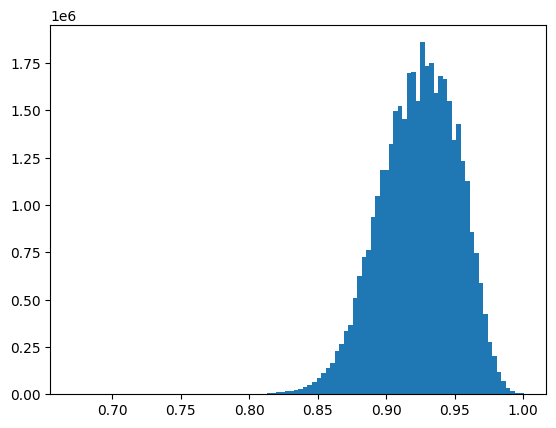

In [ ]:
plt.hist(residuals.reshape(-1).cpu().detach().numpy(), bins=100);

In [ ]:
dec_dist = inflated_decoder_learn.inject(residuals, v_dist)

In [ ]:
loss = loss_fn(dec_dist, t_dist)

In [ ]:
loss, old_original_loss

(tensor(400.5883, device='cuda:5', grad_fn=<DivBackward0>),
 tensor(401.0681, device='cuda:4'))